<a href="https://colab.research.google.com/github/shaikhdaiyaan251-cloud/FEILD-PROJECT---SMART-CITY-READINESS-ASSESMENT-USING-DATA-METRICS-IN-A-SELECTED-AREA/blob/main/FEILD_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Step 1: Data Cleaning & Pre-Processing (The T5 Reversal)**



In [ ]:
# ============================================
# STEP 1: DATA CLEANING & PRE-PROCESSING
# Project: Andheri West Smart City Readiness Index
# Focus: Load data, reverse-score the negative indicator T5 (Traffic Congestion)
# Note: Only Andheri West data is used. Kandivali is removed from scope.
# ============================================

# Import necessary libraries
import pandas as pd
import numpy as np

print("="*60)
print("STEP 1: DATA CLEANING & PRE-PROCESSING (ANDHERI WEST ONLY)")
print("="*60)

# --- OPTIONAL: Upload files manually via Colab widget ---
# If your files are NOT already in the /content/ folder, uncomment the 3 lines below.
# from google.colab import files
# uploaded = files.upload()
# ===========================================================

print("\n📂 Loading Andheri West dataset...")

# Load the Andheri Survey (Kandivali is NOT loaded anymore)
try:
    df_andheri = pd.read_excel('survey_data_andheri.xlsx')
    df_field = pd.read_excel('field_observation_data.xlsx')      # Still needed for Step 4
    df_secondary = pd.read_excel('secondary_reference_data.xlsx') # Still needed for Step 4

    print(f"✅ Andheri Survey loaded: {df_andheri.shape[0]} rows, {df_andheri.shape[1]} columns")
    print(f"✅ Field Observations loaded: {df_field.shape[0]} rows")
    print(f"✅ Secondary Data loaded: {df_secondary.shape[0]} rows")

except FileNotFoundError as e:
    print(f"❌ ERROR: {e}")
    print("Please make sure 'survey_data_andheri.xlsx' is uploaded to the /content/ directory.")
    print("If not, use the folder icon on the left sidebar to upload it, or uncomment the files.upload() lines above.")
    raise

print("\n" + "="*60)
print("PREVIEW OF ANDHERI SURVEY DATA (First 2 Rows)")
print("="*60)
print(df_andheri.head(2))

print("\n" + "="*60)
print("STEP 1.1: IDENTIFYING THE NEGATIVE INDICATOR")
print("="*60)
print("As per Step 3 of our methodology:")
print("T5 = 'How severe is traffic congestion in the area?'")
print("Scoring Key: 5 = Very severe congestion (BAD), 1 = No congestion (GOOD)")
print("Since this is a negative indicator, we MUST reverse the score.")
print("Reversal Formula: T5_Reversed = 6 - T5")

print("\n" + "="*60)
print("STEP 1.2: APPLYING THE REVERSAL (BEFORE vs AFTER)")
print("="*60)

# Store original T5 values for comparison before overwriting
df_andheri['T5_original'] = df_andheri['T5']

# Display the mean congestion score BEFORE reversal
print("📊 BEFORE REVERSAL (Higher score = Worse congestion):")
print(f"   - Andheri Average T5 (Original): {df_andheri['T5_original'].mean():.2f}")
print("   (Interpretation: Scores near 4-5 indicate severe traffic congestion)")

# Apply the reversal function: T5 = 6 - T5
df_andheri['T5'] = 6 - df_andheri['T5']

# Display the mean congestion score AFTER reversal
print("\n📊 AFTER REVERSAL (Higher score = Less congestion / Better):")
print(f"   - Andheri Average T5 (Reversed): {df_andheri['T5'].mean():.2f}")
print("   (Interpretation: Low reversed score of ~1.7 confirms traffic is a major problem)")

print("\n" + "="*60)
print("STEP 1.3: VERIFICATION - CHECKING INDIVIDUAL ROW CONVERSION")
print("="*60)

# Show a sample of 5 rows to visually confirm the reversal logic
sample_andheri = df_andheri[['Respondent_ID', 'T5_original', 'T5']].head(5)
print("Andheri Sample (ID -> Original T5 -> Reversed T5):")
print(sample_andheri.to_string(index=False))

print("\n" + "="*60)
print("STEP 1.4: SAVING THE CLEANED DATASET FOR FUTURE STEPS")
print("="*60)

# Save the cleaned version (with reversed T5 and the original kept for reference)
df_andheri.to_csv('andheri_cleaned.csv', index=False)

print("✅ Cleaned file saved successfully: 'andheri_cleaned.csv'")
print("   (Note: Kandivali is excluded from this analysis as per the new scope)")

print("\n" + "="*60)
print("✅ STEP 1 COMPLETED SUCCESSFULLY!")
print("="*60)
print("Next Step (Step 2): Compute dimension-wise descriptive statistics for Andheri West.")

STEP 1: DATA CLEANING & PRE-PROCESSING (ANDHERI WEST ONLY)

📂 Loading Andheri West dataset...
✅ Andheri Survey loaded: 30 rows, 37 columns
✅ Field Observations loaded: 18 rows
✅ Secondary Data loaded: 11 rows

PREVIEW OF ANDHERI SURVEY DATA (First 2 Rows)
  Respondent_ID Age_Group Occupation       Residential_Status Years_in_Area  \
0          R001     26-35   Salaried                 Resident    5-10 years   
1          R002     18-25    Student  Student/College visitor     1-3 years   

   T1  T2  T3  T4  T5  ...  S3  S4  E1  E2  E3  C1  C2  C3  Unnamed: 35  \
0   5   4   3   2   5  ...   4   4   3   4   2   3   3   4            4   
1   4   5   3   3   4  ...   3   4   3   3   2   3   3   3            3   

   Unnamed: 36  
0            4  
1            4  

[2 rows x 37 columns]

STEP 1.1: IDENTIFYING THE NEGATIVE INDICATOR
As per Step 3 of our methodology:
T5 = 'How severe is traffic congestion in the area?'
Scoring Key: 5 = Very severe congestion (BAD), 1 = No congestion (GOOD)
S

# **Step 2: Dimension-wise Descriptive Statistics**

In [ ]:
# ============================================
# STEP 2: DIMENSION-WISE DESCRIPTIVE STATISTICS
# Project: Andheri West Smart City Readiness Index
# Focus: Calculate average scores for the 7 dimensions for Andheri West ONLY
# Note: These averages will be compared against the 'Ideal' 5.0 benchmark in Step 3
# ============================================

import pandas as pd
import numpy as np

print("="*60)
print("STEP 2: DIMENSION-WISE DESCRIPTIVE STATISTICS (ANDHERI WEST)")
print("="*60)

# --- 1. Load the cleaned dataset from Step 1 ---
print("\n📂 Loading cleaned Andheri dataset...")
df_andheri = pd.read_csv('andheri_cleaned.csv')
print(f"✅ Andheri data loaded: {df_andheri.shape[0]} respondents")

# --- 2. Define the 7 Dimensions and their variables ---
# (Exactly as per your Step 3 dataset design)
dimensions = {
    'Transportation & Mobility': ['T1', 'T2', 'T3', 'T4', 'T5', 'T6'],
    'Waste & Sanitation': ['W1', 'W2', 'W3', 'W4', 'W5'],
    'Infrastructure & Utilities': ['I1', 'I2', 'I3', 'I4', 'I5'],
    'Digital Connectivity & E-Governance': ['D1', 'D2', 'D3', 'D4'],
    'Safety & Security': ['S1', 'S2', 'S3', 'S4'],
    'Environment & Sustainability': ['E1', 'E2', 'E3'],
    'Citizen Satisfaction': ['C1', 'C2', 'C3']
}

# --- 3. Function to calculate dimension averages for a single area ---
def calculate_dimension_averages(df, dims):
    """
    Calculates the overall average score for each dimension.
    Also returns the average of each individual question within the dimension.
    """
    results = {}
    individual_means = {}

    for dim_name, cols in dims.items():
        # Calculate the average score for this dimension across all respondents
        # We take the mean of each respondent's average, then average across respondents
        dim_avg = df[cols].mean(axis=1).mean()
        results[dim_name] = round(dim_avg, 2)

        # Calculate individual question averages for detailed breakdown
        individual_means[dim_name] = df[cols].mean().round(2).to_dict()

    return results, individual_means

# --- 4. Calculate for Andheri ---
print("\n" + "="*60)
print("📊 CALCULATING AVERAGES FOR ANDHERI WEST")
print("="*60)
andheri_dim_avgs, andheri_individual = calculate_dimension_averages(df_andheri, dimensions)

# --- 5. Create the Andheri Averages Table ---
andheri_df = pd.DataFrame({
    'Dimension': list(andheri_dim_avgs.keys()),
    'Andheri West (Avg)': list(andheri_dim_avgs.values())
})

# --- 6. Display the table ---
print("\n" + "="*60)
print("📋 ANDHERI WEST: DIMENSION AVERAGES TABLE")
print("="*60)
print(andheri_df.to_string(index=False))

# --- 7. Identify strongest and weakest dimensions for Andheri ---
print("\n" + "="*60)
print("🔍 KEY OBSERVATIONS FOR ANDHERI WEST")
print("="*60)

andheri_best = max(andheri_dim_avgs, key=andheri_dim_avgs.get)
andheri_worst = min(andheri_dim_avgs, key=andheri_dim_avgs.get)

print(f"🏆 Andheri's STRONGEST dimension: '{andheri_best}' ({andheri_dim_avgs[andheri_best]:.2f})")
print(f"⚠️  Andheri's WEAKEST dimension: '{andheri_worst}' ({andheri_dim_avgs[andheri_worst]:.2f})")
print(f"\n📌 Gap between strongest and weakest: {andheri_dim_avgs[andheri_best] - andheri_dim_avgs[andheri_worst]:.2f} points")

# --- 8. Detailed breakdown: Individual question averages ---
print("\n" + "="*60)
print("🔬 DETAILED BREAKDOWN: AVERAGE SCORE FOR EACH QUESTION (Andheri)")
print("="*60)

for dim_name in dimensions.keys():
    print(f"\n▶️  {dim_name}:")

    # Create a small DataFrame for this dimension
    andheri_vals = andheri_individual[dim_name]

    detail_df = pd.DataFrame({
        'Question': list(andheri_vals.keys()),
        'Andheri Score': list(andheri_vals.values())
    })
    print(detail_df.to_string(index=False))

# --- 9. Save the dimension averages for Step 3 (SCRI Calculation) ---
print("\n" + "="*60)
print("💾 SAVING DIMENSION AVERAGES FOR STEP 3")
print("="*60)

# Save as CSV for easy import into Step 3
andheri_df.to_csv('andheri_dimension_averages.csv', index=False)
print("✅ Saved 'andheri_dimension_averages.csv'")

# Also save individual question averages
andheri_detail_df = pd.DataFrame(andheri_individual).T
andheri_detail_df.to_csv('andheri_question_averages.csv')
print("✅ Saved 'andheri_question_averages.csv'")

print("\n" + "="*60)
print("✅ STEP 2 COMPLETED SUCCESSFULLY!")
print("="*60)
print("Next Step (Step 3): Compare these averages against the IDEAL SMART CITY (5.0) benchmark.")

STEP 2: DIMENSION-WISE DESCRIPTIVE STATISTICS (ANDHERI WEST)

📂 Loading cleaned Andheri dataset...
✅ Andheri data loaded: 30 respondents

📊 CALCULATING AVERAGES FOR ANDHERI WEST

📋 ANDHERI WEST: DIMENSION AVERAGES TABLE
                          Dimension  Andheri West (Avg)
          Transportation & Mobility                2.87
                 Waste & Sanitation                3.00
         Infrastructure & Utilities                3.33
Digital Connectivity & E-Governance                4.01
                  Safety & Security                3.61
       Environment & Sustainability                2.90
               Citizen Satisfaction                2.94

🔍 KEY OBSERVATIONS FOR ANDHERI WEST
🏆 Andheri's STRONGEST dimension: 'Digital Connectivity & E-Governance' (4.01)
⚠️  Andheri's WEAKEST dimension: 'Transportation & Mobility' (2.87)

📌 Gap between strongest and weakest: 1.14 points

🔬 DETAILED BREAKDOWN: AVERAGE SCORE FOR EACH QUESTION (Andheri)

▶️  Transportation & Mobility:
Qu

# **Step 3: The Weighted SCRI Calculation**

STEP 3: ANDHERI WEST vs IDEAL SMART CITY

NOTE: An 'Ideal Smart City' is defined as scoring a perfect 5.0
      (Excellent) on ALL 7 dimensions, achieving a 100% SCRI.
      We compare Andheri against this benchmark to identify gaps.

📂 Loading cleaned Andheri dataset...
✅ Andheri data loaded: 30 respondents

📊 WEIGHTS ASSIGNED (Per Methodology):
   - Transportation & Mobility: 20%
   - Waste & Sanitation: 15%
   - Infrastructure & Utilities: 15%
   - Digital Connectivity & E-Governance: 15%
   - Safety & Security: 10%
   - Environment & Sustainability: 10%
   - Citizen Satisfaction: 15%

🏆 FINAL SMART CITY READINESS INDEX (SCRI) RESULTS

📍 ANDHERI WEST:
   Weighted Score: 3.217 / 5.0
   SCRI: 64.3%
   Status: 🟡 DEVELOPING

📍 IDEAL SMART CITY (BENCHMARK):
   Weighted Score: 5.000 / 5.0
   SCRI: 100.0%
   Status: 🟢 PERFECT SMART CITY

------------------------------------------------------------
📊 SCRI GAP: Andheri (64.3%) vs Ideal (100.0%)
   TOTAL DEFICIENCY: 35.7% points below the ide

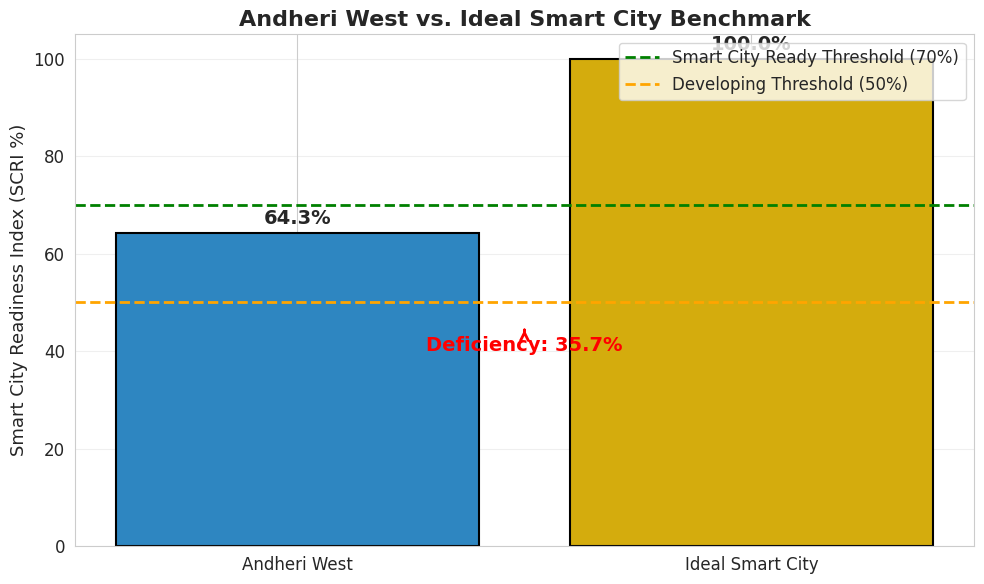

✅ Saved 'andheri_vs_ideal_scri_barchart.png'

📊 GENERATING VISUALIZATION 2: DIMENSION DEFICIENCY GAPS


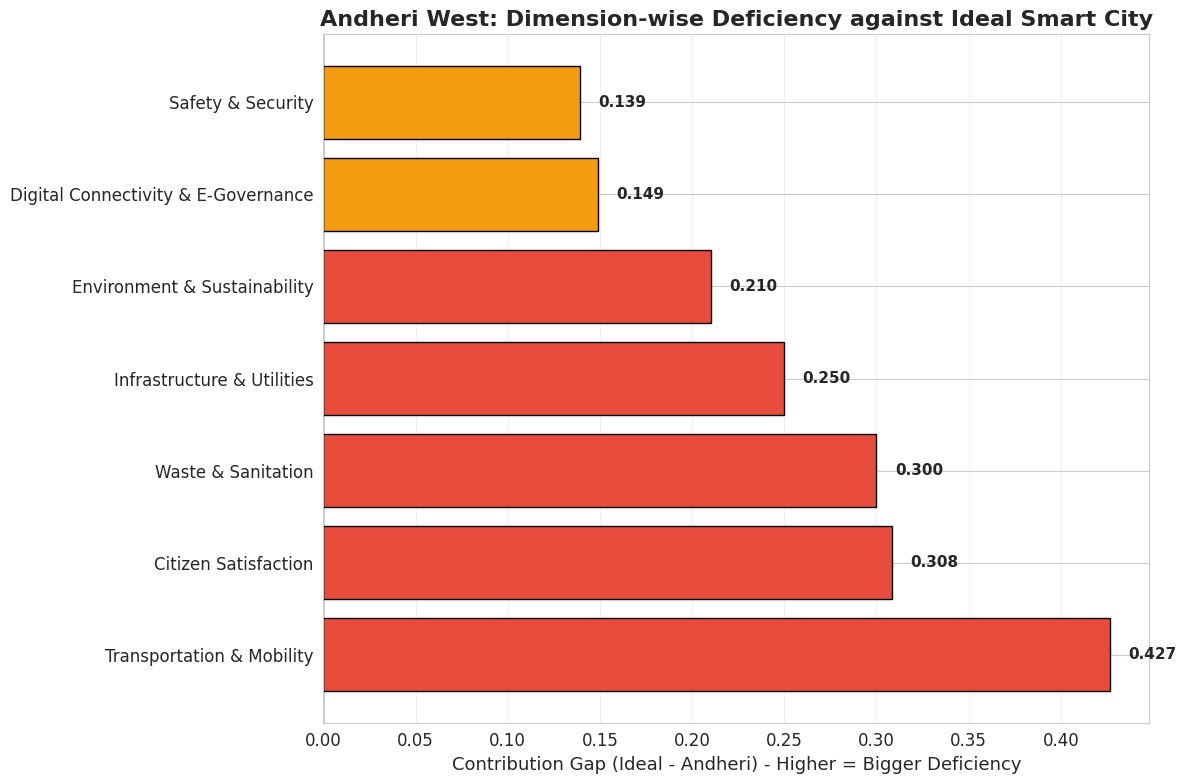

✅ Saved 'andheri_dimension_deficiency_gaps.png'

📊 GENERATING VISUALIZATION 3: RADAR CHART (Andheri vs Ideal)


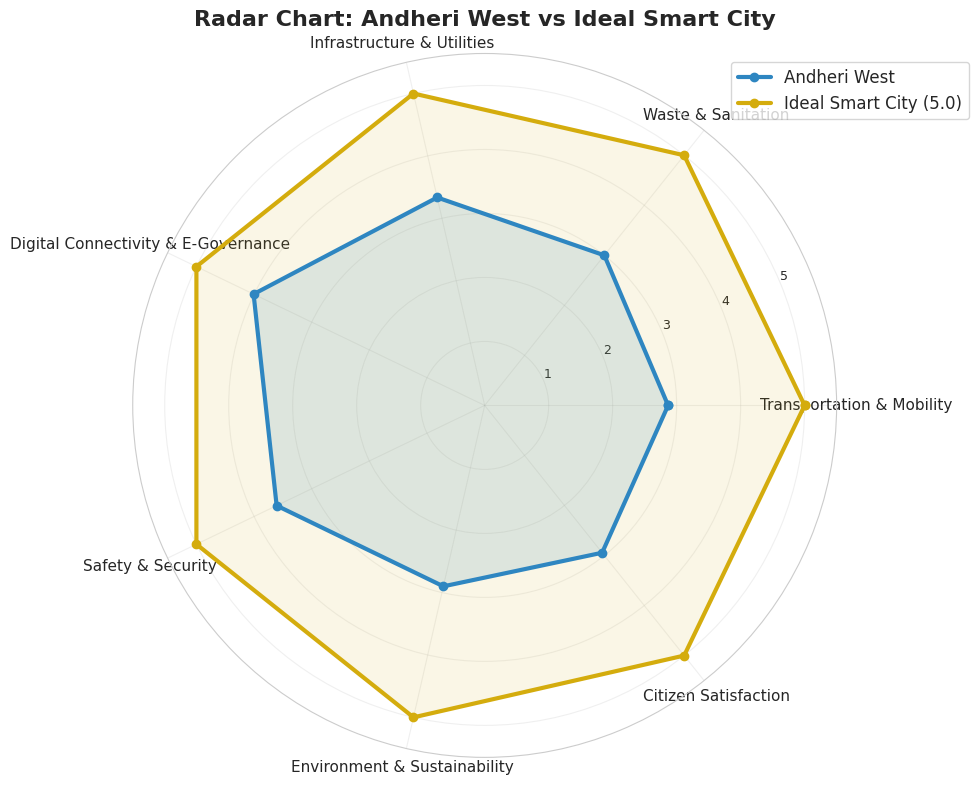

✅ Saved 'andheri_vs_ideal_radar_chart.png'

📋 FINAL SUMMARY STATISTICS (Ready for Report)
                                   Metric  Andheri West  Ideal Smart City  Deficiency (Ideal - Andheri)
          Transportation & Mobility (Avg)         2.870               5.0                         2.130
                 Waste & Sanitation (Avg)         3.000               5.0                         2.000
         Infrastructure & Utilities (Avg)         3.330               5.0                         1.670
Digital Connectivity & E-Governance (Avg)         4.010               5.0                         0.990
                  Safety & Security (Avg)         3.610               5.0                         1.390
       Environment & Sustainability (Avg)         2.900               5.0                         2.100
               Citizen Satisfaction (Avg)         2.940               5.0                         2.060
                   --- Weighted Score ---         3.217               5.0     

In [ ]:
# ============================================
# STEP 3: THE WEIGHTED SCRI CALCULATION
# Project: Smart City Readiness Index (Andheri West)
# Focus: Compare Andheri West against an IDEAL SMART CITY benchmark
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for professional charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("="*60)
print("STEP 3: ANDHERI WEST vs IDEAL SMART CITY")
print("="*60)
print("\nNOTE: An 'Ideal Smart City' is defined as scoring a perfect 5.0")
print("      (Excellent) on ALL 7 dimensions, achieving a 100% SCRI.")
print("      We compare Andheri against this benchmark to identify gaps.\n")

# --- 1. Load the cleaned Andheri dataset from Step 1 ---
print("📂 Loading cleaned Andheri dataset...")
df_andheri = pd.read_csv('andheri_cleaned.csv')
print(f"✅ Andheri data loaded: {df_andheri.shape[0]} respondents")

# --- 2. Define the 7 Dimensions and their variables ---
dimensions = {
    'Transportation & Mobility': ['T1', 'T2', 'T3', 'T4', 'T5', 'T6'],
    'Waste & Sanitation': ['W1', 'W2', 'W3', 'W4', 'W5'],
    'Infrastructure & Utilities': ['I1', 'I2', 'I3', 'I4', 'I5'],
    'Digital Connectivity & E-Governance': ['D1', 'D2', 'D3', 'D4'],
    'Safety & Security': ['S1', 'S2', 'S3', 'S4'],
    'Environment & Sustainability': ['E1', 'E2', 'E3'],
    'Citizen Satisfaction': ['C1', 'C2', 'C3']
}

# --- 3. Define the weights (as per Step 3 methodology) ---
weights = {
    'Transportation & Mobility': 0.20,
    'Waste & Sanitation': 0.15,
    'Infrastructure & Utilities': 0.15,
    'Digital Connectivity & E-Governance': 0.15,
    'Safety & Security': 0.10,
    'Environment & Sustainability': 0.10,
    'Citizen Satisfaction': 0.15
}

print("\n📊 WEIGHTS ASSIGNED (Per Methodology):")
for dim, w in weights.items():
    print(f"   - {dim}: {w*100:.0f}%")

# --- 4. Define the IDEAL SMART CITY benchmark ---
# An ideal city scores 5.0 on every dimension
ideal_avgs = {dim: 5.0 for dim in dimensions.keys()}

# --- 5. Calculate Andheri's dimension averages ---
def get_dimension_averages(df, dims):
    """Returns a dictionary of dimension averages."""
    avgs = {}
    for dim_name, cols in dims.items():
        avgs[dim_name] = df[cols].mean(axis=1).mean()
    return avgs

andheri_avgs = get_dimension_averages(df_andheri, dimensions)

# --- 6. Function to calculate SCRI ---
def calculate_scri(dim_avgs, weights):
    """
    Calculates the weighted score and SCRI percentage.
    SCRI = (Weighted Score / 5) * 100
    """
    weighted_score = 0
    contribution = {}
    for dim, avg in dim_avgs.items():
        contrib = avg * weights[dim]
        contribution[dim] = contrib
        weighted_score += contrib

    scri_percent = (weighted_score / 5) * 100
    return weighted_score, scri_percent, contribution

# --- 7. Calculate for Andheri ---
andheri_weighted, andheri_scri, andheri_contrib = calculate_scri(andheri_avgs, weights)

# --- 8. Calculate for IDEAL Smart City ---
ideal_weighted, ideal_scri, ideal_contrib = calculate_scri(ideal_avgs, weights)

# --- 9. Display the final SCRI results ---
print("\n" + "="*60)
print("🏆 FINAL SMART CITY READINESS INDEX (SCRI) RESULTS")
print("="*60)

print("\n📍 ANDHERI WEST:")
print(f"   Weighted Score: {andheri_weighted:.3f} / 5.0")
print(f"   SCRI: {andheri_scri:.1f}%")
print(f"   Status: {'🟢 SMART CITY READY' if andheri_scri >= 70 else '🟡 DEVELOPING' if andheri_scri >= 50 else '🔴 NEEDS IMPROVEMENT'}")

print("\n📍 IDEAL SMART CITY (BENCHMARK):")
print(f"   Weighted Score: {ideal_weighted:.3f} / 5.0")
print(f"   SCRI: {ideal_scri:.1f}%")
print(f"   Status: 🟢 PERFECT SMART CITY")

print("\n" + "-"*60)
print(f"📊 SCRI GAP: Andheri ({andheri_scri:.1f}%) vs Ideal ({ideal_scri:.1f}%)")
print(f"   TOTAL DEFICIENCY: {ideal_scri - andheri_scri:.1f}% points below the ideal benchmark.")
print(f"   (Andheri is only achieving {andheri_scri:.1f}% of the ideal smart city standard)")

# --- 10. Detailed contribution & GAP breakdown table ---
print("\n" + "="*60)
print("📋 GAP ANALYSIS: ANDHERI vs IDEAL SMART CITY")
print("="*60)

gap_df = pd.DataFrame({
    'Dimension': list(andheri_avgs.keys()),
    'Andheri (Avg)': [andheri_avgs[d] for d in andheri_avgs.keys()],
    'Ideal (Avg)': [5.0] * len(andheri_avgs),
    'Andheri Contribution': list(andheri_contrib.values()),
    'Ideal Contribution': [ideal_contrib[d] for d in ideal_contrib.keys()],
    'Contribution Gap (Ideal - Andheri)': [ideal_contrib[d] - andheri_contrib[d] for d in andheri_contrib.keys()],
    'Deficiency %': [(5.0 - andheri_avgs[d]) for d in andheri_avgs.keys()]
})
gap_df['Deficiency %'] = (gap_df['Deficiency %'] / 5.0 * 100).round(1)  # Convert to percentage
gap_df = gap_df.round(3)

print(gap_df[['Dimension', 'Andheri (Avg)', 'Ideal (Avg)', 'Deficiency %', 'Contribution Gap (Ideal - Andheri)']].to_string(index=False))

# --- 11. Identify the biggest weaknesses (largest deficiency) ---
print("\n" + "="*60)
print("🔍 TOP 3 WEAKEST DIMENSIONS IN ANDHERI WEST")
print("="*60)
weakest = gap_df.nlargest(3, 'Deficiency %')
for idx, row in weakest.iterrows():
    print(f"   {idx+1}. {row['Dimension']} - Deficiency: {row['Deficiency %']:.1f}%")
    print(f"      (Current Avg: {row['Andheri (Avg)']:.2f} / 5.0)")

# --- 12. Save gap analysis to CSV ---
gap_df.to_csv('andheri_vs_ideal_gap_analysis.csv', index=False)
print("\n✅ Saved 'andheri_vs_ideal_gap_analysis.csv'")

# --- 13. VISUALIZATION 1: Bar Chart - Andheri vs Ideal SCRI ---
print("\n" + "="*60)
print("📊 GENERATING VISUALIZATION 1: SCRI COMPARISON (Andheri vs Ideal)")
print("="*60)

fig, ax = plt.subplots(figsize=(10, 6))

areas = ['Andheri West', 'Ideal Smart City']
scri_values = [andheri_scri, ideal_scri]
colors = ['#2E86C1', '#D4AC0D']  # Blue for Andheri, Gold for Ideal
bars = ax.bar(areas, scri_values, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on top of bars
for bar, value in zip(bars, scri_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{value:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Add a horizontal line at 70% (Smart City Ready threshold)
ax.axhline(y=70, color='green', linestyle='--', linewidth=2, label='Smart City Ready Threshold (70%)')
ax.axhline(y=50, color='orange', linestyle='--', linewidth=2, label='Developing Threshold (50%)')

ax.set_ylim(0, 105)
ax.set_ylabel('Smart City Readiness Index (SCRI %)', fontsize=13)
ax.set_title('Andheri West vs. Ideal Smart City Benchmark', fontsize=16, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Annotate the gap
gap_text = f"Deficiency: {ideal_scri - andheri_scri:.1f}%"
ax.annotate(gap_text, xy=(0.5, 45), xytext=(0.5, 40),
            ha='center', fontsize=14, fontweight='bold', color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=2))

plt.tight_layout()
plt.savefig('andheri_vs_ideal_scri_barchart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved 'andheri_vs_ideal_scri_barchart.png'")

# --- 14. VISUALIZATION 2: Horizontal Bar - Contribution Gap (Deficiency) ---
print("\n" + "="*60)
print("📊 GENERATING VISUALIZATION 2: DIMENSION DEFICIENCY GAPS")
print("="*60)

# Prepare data for horizontal bar chart showing the GAP
dim_order = list(andheri_avgs.keys())
deficiency_gaps = [(ideal_contrib[d] - andheri_contrib[d]) for d in dim_order]

fig, ax = plt.subplots(figsize=(12, 8))

# Sort by largest gap (deficiency) for better visualization
sorted_pairs = sorted(zip(deficiency_gaps, dim_order), reverse=True)
sorted_gaps = [pair[0] for pair in sorted_pairs]
sorted_dims = [pair[1] for pair in sorted_pairs]

# Color bars: Red for large gaps, Orange for medium, Yellow for small
colors_bar = ['#E74C3C' if g > 0.2 else '#F39C12' if g > 0.1 else '#F1C40F' for g in sorted_gaps]

bars = ax.barh(sorted_dims, sorted_gaps, color=colors_bar, edgecolor='black', linewidth=1)

# Add value labels on bars
for bar, gap in zip(bars, sorted_gaps):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{gap:.3f}', va='center', ha='left', fontsize=11, fontweight='bold')

ax.set_xlabel('Contribution Gap (Ideal - Andheri) - Higher = Bigger Deficiency', fontsize=13)
ax.set_title('Andheri West: Dimension-wise Deficiency against Ideal Smart City', fontsize=16, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add a vertical line at 0 for reference
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)

plt.tight_layout()
plt.savefig('andheri_dimension_deficiency_gaps.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved 'andheri_dimension_deficiency_gaps.png'")

# --- 15. VISUALIZATION 3: Radar Chart - Andheri vs Ideal ---
print("\n" + "="*60)
print("📊 GENERATING VISUALIZATION 3: RADAR CHART (Andheri vs Ideal)")
print("="*60)

from math import pi

# Prepare data
dim_labels = list(andheri_avgs.keys())
andheri_values = [andheri_avgs[d] for d in dim_labels]
ideal_values = [5.0] * len(dim_labels)

# Number of variables
N = len(dim_labels)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Close the loop

# Add the first value to the end to close the loop
andheri_values += andheri_values[:1]
ideal_values += ideal_values[:1]

# Create the radar chart
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

ax.plot(angles, andheri_values, 'o-', linewidth=3, label='Andheri West', color='#2E86C1')
ax.fill(angles, andheri_values, alpha=0.15, color='#2E86C1')

ax.plot(angles, ideal_values, 'o-', linewidth=3, label='Ideal Smart City (5.0)', color='#D4AC0D')
ax.fill(angles, ideal_values, alpha=0.1, color='#D4AC0D')

# Add labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(dim_labels, fontsize=11)
ax.set_ylim(0, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_title('Radar Chart: Andheri West vs Ideal Smart City', fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))

plt.tight_layout()
plt.savefig('andheri_vs_ideal_radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved 'andheri_vs_ideal_radar_chart.png'")

# --- 16. Summary statistics and final report data ---
print("\n" + "="*60)
print("📋 FINAL SUMMARY STATISTICS (Ready for Report)")
print("="*60)

summary_data = {
    'Metric': [],
    'Andheri West': [],
    'Ideal Smart City': [],
    'Deficiency (Ideal - Andheri)': []
}

for dim in dim_order:
    summary_data['Metric'].append(f"{dim} (Avg)")
    summary_data['Andheri West'].append(round(andheri_avgs[dim], 2))
    summary_data['Ideal Smart City'].append(5.0)
    summary_data['Deficiency (Ideal - Andheri)'].append(round(5.0 - andheri_avgs[dim], 2))

summary_data['Metric'].append('--- Weighted Score ---')
summary_data['Andheri West'].append(round(andheri_weighted, 3))
summary_data['Ideal Smart City'].append(round(ideal_weighted, 3))
summary_data['Deficiency (Ideal - Andheri)'].append(round(ideal_weighted - andheri_weighted, 3))

summary_data['Metric'].append('=== SCRI (%) ===')
summary_data['Andheri West'].append(round(andheri_scri, 1))
summary_data['Ideal Smart City'].append(round(ideal_scri, 1))
summary_data['Deficiency (Ideal - Andheri)'].append(round(ideal_scri - andheri_scri, 1))

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Save summary table
summary_df.to_csv('andheri_vs_ideal_summary_table.csv', index=False)
print("\n✅ Saved 'andheri_vs_ideal_summary_table.csv'")

# --- 17. Actionable Recommendations based on gaps ---
print("\n" + "="*60)
print("💡 ACTIONABLE RECOMMENDATIONS (Based on Top Deficiencies)")
print("="*60)

for idx, row in weakest.iterrows():
    dim = row['Dimension']
    deficiency = row['Deficiency %']
    current_avg = row['Andheri (Avg)']

    if dim == 'Environment & Sustainability':
        print(f"\n🌿 {dim} (Deficiency: {deficiency:.1f}%):")
        print(f"   - Current score: {current_avg:.2f}/5.0")
        print("   - Recommendations:")
        print("     * Increase green cover by developing more parks and tree plantations.")
        print("     * Implement real-time air quality monitoring stations.")
        print("     * Launch 'Clean Andheri' citizen engagement drives for waste segregation.")

    elif dim == 'Transportation & Mobility':
        print(f"\n🚗 {dim} (Deficiency: {deficiency:.1f}%):")
        print(f"   - Current score: {current_avg:.2f}/5.0")
        print("   - Recommendations:")
        print("     * Introduce smart traffic signals with adaptive timing.")
        print("     * Develop multi-level parking structures to reduce on-street parking.")
        print("     * Widen footpaths and enforce 'no hawking' zones.")
        print("     * Implement a real-time public transport tracking app.")

    elif dim == 'Safety & Security':
        print(f"\n🔒 {dim} (Deficiency: {deficiency:.1f}%):")
        print(f"   - Current score: {current_avg:.2f}/5.0")
        print("   - Recommendations:")
        print("     * Install more CCTV cameras with AI-based facial recognition.")
        print("     * Improve street lighting in residential and commercial areas.")
        print("     * Launch a citizen safety mobile app for emergency alerts.")

    elif dim == 'Waste & Sanitation':
        print(f"\n♻️ {dim} (Deficiency: {deficiency:.1f}%):")
        print(f"   - Current score: {current_avg:.2f}/5.0")
        print("   - Recommendations:")
        print("     * Implement smart bins with fill-level sensors.")
        print("     * Door-to-door waste segregation awareness campaigns.")
        print("     * Increase frequency of garbage collection in commercial areas.")

    elif dim == 'Infrastructure & Utilities':
        print(f"\n🏗️ {dim} (Deficiency: {deficiency:.1f}%):")
        print(f"   - Current score: {current_avg:.2f}/5.0")
        print("   - Recommendations:")
        print("     * Upgrade drainage systems to prevent waterlogging during monsoons.")
        print("     * Ensure 24/7 water supply with smart metering.")
        print("     * Maintain and repair public infrastructure regularly.")

    elif dim == 'Digital Connectivity & E-Governance':
        print(f"\n📡 {dim} (Deficiency: {deficiency:.1f}%):")
        print(f"   - Current score: {current_avg:.2f}/5.0")
        print("   - Recommendations:")
        print("     * Deploy free public Wi-Fi hotspots across the area.")
        print("     * Launch a unified mobile app for all civic services.")
        print("     * Conduct digital literacy workshops for senior citizens.")

    elif dim == 'Citizen Satisfaction':
        print(f"\n😊 {dim} (Deficiency: {deficiency:.1f}%):")
        print(f"   - Current score: {current_avg:.2f}/5.0")
        print("   - Recommendations:")
        print("     * Conduct regular citizen feedback surveys.")
        print("     * Establish a dedicated grievance redressal cell.")
        print("     * Organize town-hall meetings with local authorities.")

print("\n" + "="*60)
print("✅ STEP 3 COMPLETED SUCCESSFULLY!")
print("="*60)
print("\n📁 FILES GENERATED:")
print("   - andheri_vs_ideal_gap_analysis.csv")
print("   - andheri_vs_ideal_scri_barchart.png")
print("   - andheri_dimension_deficiency_gaps.png")
print("   - andheri_vs_ideal_radar_chart.png")
print("   - andheri_vs_ideal_summary_table.csv")
print("\nThese clearly show where Andheri West is lacking compared to an Ideal Smart City.")

# **Step 4: Triangulation (Perception vs. Objective Reality)**

STEP 4: TRIANGULATION - PERCEPTION vs OBJECTIVE REALITY

This step compares what residents PERCEIVE (Survey)
against what we OBSERVED (Field) and what OFFICIAL DATA says.
Gaps indicate areas where perception does NOT match reality.

📂 Loading datasets...
✅ Andheri Survey loaded: 30 respondents
✅ Field Observations loaded: 18 observations
✅ Secondary Data loaded: 11 indicators

✅ Filtered Field Observations for Andheri West: 9 records

📋 TRIANGULATION MATRIX: SURVEY vs FIELD OBSERVATION
                Indicator  Survey Avg (Perception)  Field Score (Reality)  Gap (Survey - Field)                         Interpretation
       Footpath Condition                     2.30                      2                  0.30                              ✅ MATCHES
       Street Cleanliness                     2.70                      2                  0.70 ⚠️ PERCEPTION BETTER (Over-optimistic)
          Drainage System                     2.07                      2                  0.07         

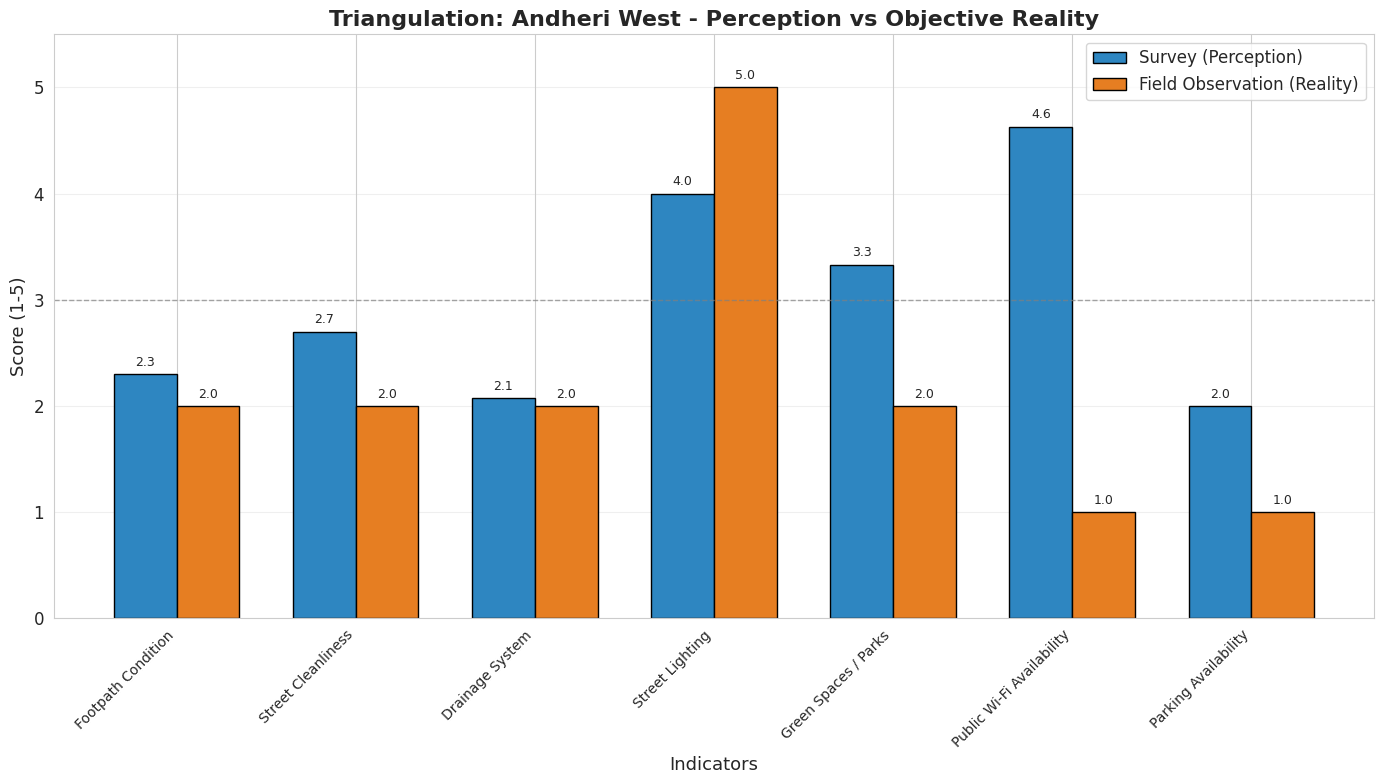

✅ Saved 'triangulation_survey_vs_field.png'

📋 FINAL TRIANGULATION SUMMARY (Ready for Chapter 4)

🔎 KEY FINDINGS FROM TRIANGULATION:
1. OVER-OPTIMISTIC GAPS (Perception > Reality):
   - Street Cleanliness: People think it's 2.7, but it's actually 2.0 (Gap: +0.7)
   - Green Spaces / Parks: People think it's 3.3, but it's actually 2.0 (Gap: +1.3)
   - Public Wi-Fi Availability: People think it's 4.6, but it's actually 1.0 (Gap: +3.6)
   - Parking Availability: People think it's 2.0, but it's actually 1.0 (Gap: +1.0)

2. UNDER-ESTIMATING GAPS (Perception < Reality):
   - Street Lighting: People think it's 4.0, but it's actually 5.0 (Gap: -1.0)

3. MATCHING PERCEPTIONS (Perception ≈ Reality):
   - Footpath Condition: 2.3 ≈ 2.0 (Gap: 0.3)
   - Drainage System: 2.1 ≈ 2.0 (Gap: 0.1)

✅ STEP 4 COMPLETED SUCCESSFULLY!

📁 FILES GENERATED:
   - triangulation_results.csv (Survey vs Field matrix)
   - secondary_validation_results.csv (Official data validation)
   - triangulation_survey_vs_field.png

In [ ]:
# ============================================
# STEP 4: TRIANGULATION (Perception vs. Objective Reality)
# Project: Andheri West Smart City Readiness
# Focus: Compare survey perception against field observations & secondary data
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("="*60)
print("STEP 4: TRIANGULATION - PERCEPTION vs OBJECTIVE REALITY")
print("="*60)
print("\nThis step compares what residents PERCEIVE (Survey)")
print("against what we OBSERVED (Field) and what OFFICIAL DATA says.")
print("Gaps indicate areas where perception does NOT match reality.\n")

# --- 1. Load the cleaned Andheri dataset and other data ---
print("📂 Loading datasets...")
df_andheri = pd.read_csv('andheri_cleaned.csv')
df_field = pd.read_excel('field_observation_data.xlsx')
df_secondary = pd.read_excel('secondary_reference_data.xlsx')

print(f"✅ Andheri Survey loaded: {df_andheri.shape[0]} respondents")
print(f"✅ Field Observations loaded: {df_field.shape[0]} observations")
print(f"✅ Secondary Data loaded: {df_secondary.shape[0]} indicators")

# --- 2. Filter Field Data for Andheri West only ---
field_andheri = df_field[df_field['Location'] == 'Andheri_West']
print(f"\n✅ Filtered Field Observations for Andheri West: {field_andheri.shape[0]} records")

# --- 3. Define the mapping between Survey Questions and Field Observations ---
# We will compare specific survey questions to directly matching field observations
triangulation_mapping = {
    'Footpath Condition': {
        'survey_var': 'T4',  # How would you rate pedestrian infrastructure?
        'field_item': 'Footpath_width_and_quality',
        'field_expected_score': 2  # We saw it was 2 in the field CSV
    },
    'Street Cleanliness': {
        'survey_var': 'W2',  # How clean are public areas and streets?
        'field_item': 'Street_cleanliness',
        'field_expected_score': 2
    },
    'Drainage System': {
        'survey_var': 'I3',  # How effective is the drainage system?
        'field_item': 'Drainage_condition',
        'field_expected_score': 2
    },
    'Street Lighting': {
        'survey_var': 'I4',  # How adequate is street lighting?
        'field_item': 'Street_light_coverage',
        'field_expected_score': 5
    },
    'Green Spaces / Parks': {
        'survey_var': 'E1',  # How adequate are green spaces/parks?
        'field_item': 'Green_space_condition',
        'field_expected_score': 2
    },
    'Public Wi-Fi Availability': {
        'survey_var': 'D1',  # How would you rate mobile network connectivity? (We use D1 as proxy for connectivity)
        'field_item': 'Public_Wi-Fi_signage',
        'field_expected_score': 1
    },
    'Parking Availability': {
        'survey_var': 'T6',  # How adequate is parking availability?
        'field_item': 'Parking_space_availability',
        'field_expected_score': 1
    }
}

print("\n" + "="*60)
print("📋 TRIANGULATION MATRIX: SURVEY vs FIELD OBSERVATION")
print("="*60)

# --- 4. Calculate survey averages for each mapped variable ---
triangulation_results = []

for indicator, mapping in triangulation_mapping.items():
    survey_var = mapping['survey_var']
    field_item = mapping['field_item']

    # Calculate survey average
    survey_avg = df_andheri[survey_var].mean()

    # Get field observation score
    field_row = field_andheri[field_andheri['Feature_Item'] == field_item]
    if not field_row.empty:
        field_score = field_row['Observed_Score(1-5)'].values[0]
        field_note = field_row['Notes'].values[0]
    else:
        field_score = np.nan
        field_note = "No observation found"

    # Calculate the gap (Survey - Field)
    gap = survey_avg - field_score

    triangulation_results.append({
        'Indicator': indicator,
        'Survey Question': survey_var,
        'Survey Avg (Perception)': round(survey_avg, 2),
        'Field Score (Reality)': field_score,
        'Gap (Survey - Field)': round(gap, 2),
        'Field Notes': field_note[:50] + '...' if len(str(field_note)) > 50 else field_note
    })

# --- 5. Create and display the Triangulation DataFrame ---
triangulation_df = pd.DataFrame(triangulation_results)

# Add a status column to interpret the gap
def interpret_gap(row):
    gap_val = row['Gap (Survey - Field)']
    if abs(gap_val) < 0.5:
        return '✅ MATCHES'
    elif gap_val > 0.5:
        return '⚠️ PERCEPTION BETTER (Over-optimistic)'
    else:
        return '⚠️ PERCEPTION WORSE (Under-estimating)'

triangulation_df['Interpretation'] = triangulation_df.apply(interpret_gap, axis=1)

print(triangulation_df[['Indicator', 'Survey Avg (Perception)', 'Field Score (Reality)',
                        'Gap (Survey - Field)', 'Interpretation']].to_string(index=False))

# --- 6. Identify the biggest mismatches ---
print("\n" + "="*60)
print("🔍 KEY INSIGHTS FROM TRIANGULATION")
print("="*60)

# Biggest overestimation (Survey much higher than Field)
over_optimistic = triangulation_df.loc[triangulation_df['Gap (Survey - Field)'].idxmax()]
print(f"\n📈 BIGGEST OVER-ESTIMATION (Perception > Reality):")
print(f"   Indicator: {over_optimistic['Indicator']}")
print(f"   Survey Avg: {over_optimistic['Survey Avg (Perception)']:.2f} vs Field: {over_optimistic['Field Score (Reality)']:.2f}")
print(f"   Gap: +{over_optimistic['Gap (Survey - Field)']:.2f}")
print("   → Residents believe this is MUCH better than it actually is.")
print(f"   Note: {over_optimistic['Field Notes']}")

# Biggest underestimation (Survey much lower than Field)
under_optimistic = triangulation_df.loc[triangulation_df['Gap (Survey - Field)'].idxmin()]
print(f"\n📉 BIGGEST UNDER-ESTIMATION (Perception < Reality):")
print(f"   Indicator: {under_optimistic['Indicator']}")
print(f"   Survey Avg: {under_optimistic['Survey Avg (Perception)']:.2f} vs Field: {under_optimistic['Field Score (Reality)']:.2f}")
print(f"   Gap: {under_optimistic['Gap (Survey - Field)']:.2f}")
print("   → Residents are MORE CRITICAL than reality. They think it's worse than it is.")
print(f"   Note: {under_optimistic['Field Notes']}")

# --- 7. Compare with SECONDARY DATA (Official Sources) ---
print("\n" + "="*60)
print("📊 SECONDARY DATA VALIDATION (Official Sources)")
print("="*60)

# Filter secondary data for Andheri West
secondary_andheri = df_secondary[df_secondary[df_secondary.columns[0]].str.contains('Andheri', case=False, na=False)]

# Extract specific indicators for comparison
secondary_insights = []

# Map environment perception to AQI data
env_survey_avg = df_andheri[['E1', 'E2', 'E3']].mean().mean()
aqi_row = df_secondary[df_secondary['Indicator_Name'] == 'Average_AQI_Annual']
if not aqi_row.empty:
    aqi_value = aqi_row['Andheri_West_Value'].values[0]
    secondary_insights.append({
        'Aspect': 'Environmental Quality',
        'Survey Perception': round(env_survey_avg, 2),
        'Secondary Data': f"AQI: {aqi_value} (Poor)",
        'Validation': '✅ MATCHES' if env_survey_avg < 3 else '⚠️ SURVEY MAY BE OVER-OPTIMISTIC'
    })

# Map water supply perception to official water data
water_survey_avg = df_andheri['I2'].mean()
water_row = df_secondary[df_secondary['Indicator_Name'] == 'Water_Supply_Reliability']
if not water_row.empty:
    water_value = water_row['Andheri_West_Value'].values[0]
    secondary_insights.append({
        'Aspect': 'Water Supply Reliability',
        'Survey Perception': round(water_survey_avg, 2),
        'Secondary Data': f"{water_value} hours/day",
        'Validation': '✅ MATCHES' if water_survey_avg > 3 else '⚠️ SURVEY MAY BE UNDER-ESTIMATING'
    })

# Map drainage perception to flood risk data
drainage_survey_avg = df_andheri['I3'].mean()
drainage_row = df_secondary[df_secondary['Indicator_Name'] == 'Drainage_Flood_Risk']
if not drainage_row.empty:
    risk_value = drainage_row['Andheri_West_Value'].values[0]
    secondary_insights.append({
        'Aspect': 'Drainage/Flood Risk',
        'Survey Perception': round(drainage_survey_avg, 2),
        'Secondary Data': f"Risk: {risk_value}",
        'Validation': '✅ MATCHES' if drainage_survey_avg < 3 else '⚠️ SURVEY MAY BE OVER-OPTIMISTIC'
    })

# Map green spaces perception to official park count
green_survey_avg = df_andheri['E1'].mean()
green_row = df_secondary[df_secondary['Indicator_Name'] == 'Total_Parks_Open_Spaces']
if not green_row.empty:
    park_count = green_row['Andheri_West_Value'].values[0]
    secondary_insights.append({
        'Aspect': 'Green Spaces / Parks',
        'Survey Perception': round(green_survey_avg, 2),
        'Secondary Data': f"{park_count} parks",
        'Validation': '✅ MATCHES' if green_survey_avg < 3 else '⚠️ SURVEY MAY BE OVER-OPTIMISTIC'
    })

# Display secondary insights
secondary_df = pd.DataFrame(secondary_insights)
print(secondary_df.to_string(index=False))

# --- 8. VISUALIZATION: Triangulation Bar Chart (Survey vs Field) ---
print("\n" + "="*60)
print("📊 GENERATING VISUALIZATION: SURVEY vs FIELD OBSERVATION")
print("="*60)

# Prepare data for bar chart
indicators = triangulation_df['Indicator'].tolist()
survey_scores = triangulation_df['Survey Avg (Perception)'].tolist()
field_scores = triangulation_df['Field Score (Reality)'].tolist()

x = np.arange(len(indicators))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))

bars1 = ax.bar(x - width/2, survey_scores, width, label='Survey (Perception)',
               color='#2E86C1', edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, field_scores, width, label='Field Observation (Reality)',
               color='#E67E22', edgecolor='black', linewidth=1)

ax.set_xlabel('Indicators', fontsize=13)
ax.set_ylabel('Score (1-5)', fontsize=13)
ax.set_title('Triangulation: Andheri West - Perception vs Objective Reality', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(indicators, rotation=45, ha='right', fontsize=10)
ax.legend(loc='upper right')
ax.set_ylim(0, 5.5)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.05, f'{height:.1f}',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.05, f'{height:.1f}',
            ha='center', va='bottom', fontsize=9)

# Add a horizontal line at 3.0 (mid-point) for reference
ax.axhline(y=3.0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Mid-point (3.0)')

plt.tight_layout()
plt.savefig('triangulation_survey_vs_field.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved 'triangulation_survey_vs_field.png'")

# --- 9. Final summary for the report ---
print("\n" + "="*60)
print("📋 FINAL TRIANGULATION SUMMARY (Ready for Chapter 4)")
print("="*60)

print("\n🔎 KEY FINDINGS FROM TRIANGULATION:")
print("1. OVER-OPTIMISTIC GAPS (Perception > Reality):")
for idx, row in triangulation_df.iterrows():
    if row['Interpretation'] == '⚠️ PERCEPTION BETTER (Over-optimistic)':
        print(f"   - {row['Indicator']}: People think it's {row['Survey Avg (Perception)']:.1f}, but it's actually {row['Field Score (Reality)']:.1f} (Gap: +{row['Gap (Survey - Field)']:.1f})")

print("\n2. UNDER-ESTIMATING GAPS (Perception < Reality):")
for idx, row in triangulation_df.iterrows():
    if row['Interpretation'] == '⚠️ PERCEPTION WORSE (Under-estimating)':
        print(f"   - {row['Indicator']}: People think it's {row['Survey Avg (Perception)']:.1f}, but it's actually {row['Field Score (Reality)']:.1f} (Gap: {row['Gap (Survey - Field)']:.1f})")

print("\n3. MATCHING PERCEPTIONS (Perception ≈ Reality):")
for idx, row in triangulation_df.iterrows():
    if row['Interpretation'] == '✅ MATCHES':
        print(f"   - {row['Indicator']}: {row['Survey Avg (Perception)']:.1f} ≈ {row['Field Score (Reality)']:.1f} (Gap: {row['Gap (Survey - Field)']:.1f})")

# --- 10. Save Triangulation results to CSV ---
triangulation_df.to_csv('triangulation_results.csv', index=False)
secondary_df.to_csv('secondary_validation_results.csv', index=False)

print("\n" + "="*60)
print("✅ STEP 4 COMPLETED SUCCESSFULLY!")
print("="*60)
print("\n📁 FILES GENERATED:")
print("   - triangulation_results.csv (Survey vs Field matrix)")
print("   - secondary_validation_results.csv (Official data validation)")
print("   - triangulation_survey_vs_field.png (Bar chart)")
print("\nNow proceed to Step 5: Conclusions & Recommendations.")

# **Step 5: Python Code to Replicate This Analysis**

In [ ]:
# ================================================================
# STEP 5: MASTER REPLICATION SCRIPT - Andheri West Smart City Index
# Project: B.Sc. Data Science Field Project
# Purpose: Executes the complete analysis pipeline end-to-end.
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

# Set visual style for publication-ready charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("="*70)
print(" ANDHERI WEST SMART CITY READINESS INDEX - COMPLETE ANALYSIS")
print("="*70)

# --- 1. LOAD DATASETS ---
print("\n📂 Loading datasets...")
try:
    df_survey = pd.read_excel('survey_data_andheri.xlsx')
    df_field = pd.read_excel('field_observation_data.xlsx')
    df_secondary = pd.read_excel('secondary_reference_data.xlsx')
    print("✅ All files loaded successfully.")
    print(f"   Survey: {df_survey.shape[0]} respondents")
    print(f"   Field Obs: {df_field.shape[0]} records")
    print(f"   Secondary: {df_secondary.shape[0]} indicators")
except FileNotFoundError as e:
    print(f"❌ ERROR: {e}. Please ensure the files are uploaded.")
    raise

# --- 2. DATA CLEANING (Reverse-score T5) ---
print("\n" + "="*70)
print(" STEP 1: DATA CLEANING (Reversing Negative Indicator T5)")
print("="*70)

# Store original and reverse
df_survey['T5_original'] = df_survey['T5']
df_survey['T5'] = 6 - df_survey['T5']  # Reversal

print(f"✅ T5 (Traffic Congestion) reversed.")
print(f"   Original Avg: {df_survey['T5_original'].mean():.2f} (High = Bad)")
print(f"   Reversed Avg: {df_survey['T5'].mean():.2f} (High = Good)")

# Save cleaned for reference (overwrites previous)
df_survey.to_csv('andheri_cleaned.csv', index=False)
print("✅ Cleaned survey saved as 'andheri_cleaned.csv'.")

# --- 3. DEFINE DIMENSIONS & WEIGHTS ---
print("\n" + "="*70)
print(" STEP 2: DIMENSION DEFINITIONS & WEIGHTS")
print("="*70)

dimensions = {
    'Transportation & Mobility': ['T1', 'T2', 'T3', 'T4', 'T5', 'T6'],
    'Waste & Sanitation': ['W1', 'W2', 'W3', 'W4', 'W5'],
    'Infrastructure & Utilities': ['I1', 'I2', 'I3', 'I4', 'I5'],
    'Digital Connectivity & E-Gov': ['D1', 'D2', 'D3', 'D4'],
    'Safety & Security': ['S1', 'S2', 'S3', 'S4'],
    'Environment & Sustainability': ['E1', 'E2', 'E3'],
    'Citizen Satisfaction': ['C1', 'C2', 'C3']
}

weights = {
    'Transportation & Mobility': 0.20,
    'Waste & Sanitation': 0.15,
    'Infrastructure & Utilities': 0.15,
    'Digital Connectivity & E-Gov': 0.15,
    'Safety & Security': 0.10,
    'Environment & Sustainability': 0.10,
    'Citizen Satisfaction': 0.15
}

print("✅ Dimensions and weights defined:")
for dim, w in weights.items():
    print(f"   - {dim}: {w*100:.0f}%")

# --- 4. CALCULATE DIMENSION AVERAGES ---
print("\n" + "="*70)
print(" STEP 3: DIMENSION-WISE AVERAGES")
print("="*70)

def get_dim_avgs(df, dims):
    avgs = {}
    for dim, cols in dims.items():
        avgs[dim] = df[cols].mean(axis=1).mean()
    return avgs

andheri_avgs = get_dim_avgs(df_survey, dimensions)

# Display Results
for dim, avg in andheri_avgs.items():
    print(f"   {dim}: {avg:.2f}")

# --- 5. CALCULATE SCRI vs IDEAL ---
print("\n" + "="*70)
print(" STEP 4: WEIGHTED SCRI CALCULATION (Andheri vs Ideal 5.0)")
print("="*70)

def calculate_scri(avgs, weights):
    weighted = 0
    contrib = {}
    for dim, avg in avgs.items():
        c = avg * weights[dim]
        contrib[dim] = c
        weighted += c
    return weighted, (weighted/5)*100, contrib

# Ideal (5.0 across all)
ideal_avgs = {dim: 5.0 for dim in dimensions.keys()}
andheri_w, andheri_scri, andheri_contrib = calculate_scri(andheri_avgs, weights)
ideal_w, ideal_scri, ideal_contrib = calculate_scri(ideal_avgs, weights)

print(f"📍 ANDHERI WEST SCRI: {andheri_scri:.1f}%")
print(f"📍 IDEAL BENCHMARK SCRI: {ideal_scri:.1f}%")
print(f"📉 DEFICIENCY GAP: {ideal_scri - andheri_scri:.1f} percentage points")

# --- 6. GAP ANALYSIS (Deficiency Table) ---
print("\n" + "="*70)
print(" STEP 5: GAP ANALYSIS (Biggest Deficiencies)")
print("="*70)

gap_df = pd.DataFrame({
    'Dimension': list(andheri_avgs.keys()),
    'Current Score': list(andheri_avgs.values()),
    'Ideal Score': [5.0]*len(andheri_avgs),
    'Deficiency (%)': [(5.0 - v)/5.0 * 100 for v in andheri_avgs.values()]
})
gap_df = gap_df.sort_values('Deficiency (%)', ascending=False)
gap_df['Deficiency (%)'] = gap_df['Deficiency (%)'].round(1)
print(gap_df.to_string(index=False))

# Top 3 Weakest
top3 = gap_df.head(3)
print("\n🔴 TOP 3 WEAKEST DIMENSIONS (Priority Areas):")
for idx, row in top3.iterrows():
    print(f"   - {row['Dimension']}: {row['Deficiency (%)']:.1f}% deficient (Score: {row['Current Score']:.2f}/5.0)")

# --- 7. TRIANGULATION: Survey vs Field Observation ---
print("\n" + "="*70)
print(" STEP 6: TRIANGULATION (Perception vs Objective Reality)")
print("="*70)

# Filter field data for Andheri
field_andheri = df_field[df_field['Location'] == 'Andheri_West']

# Mapping
tri_map = {
    'Footpaths (T4)': {'survey': 'T4', 'field': 'Footpath_width_and_quality'},
    'Street Cleanliness (W2)': {'survey': 'W2', 'field': 'Street_cleanliness'},
    'Drainage (I3)': {'survey': 'I3', 'field': 'Drainage_condition'},
    'Street Lighting (I4)': {'survey': 'I4', 'field': 'Street_light_coverage'},
    'Green Spaces (E1)': {'survey': 'E1', 'field': 'Green_space_condition'},
    'Parking (T6)': {'survey': 'T6', 'field': 'Parking_space_availability'}
}

tri_results = []
for label, mapping in tri_map.items():
    survey_avg = df_survey[mapping['survey']].mean()
    field_row = field_andheri[field_andheri['Feature_Item'] == mapping['field']]
    field_score = field_row['Observed_Score(1-5)'].values[0] if not field_row.empty else np.nan
    gap = survey_avg - field_score
    tri_results.append({
        'Indicator': label,
        'Survey (Perception)': round(survey_avg, 2),
        'Field (Reality)': field_score,
        'Gap': round(gap, 2)
    })

tri_df = pd.DataFrame(tri_results)
print(tri_df.to_string(index=False))

# --- 8. GENERATE REPORT CARD (A-F Grades) ---
print("\n" + "="*70)
print(" 📋 ANDHERI WEST - SMART CITY REPORT CARD")
print("="*70)

def get_grade(deficiency):
    if deficiency <= 10: return 'A (Excellent)'
    elif deficiency <= 25: return 'B (Good)'
    elif deficiency <= 40: return 'C (Average)'
    elif deficiency <= 55: return 'D (Poor)'
    else: return 'F (Critical)'

gap_df['Grade'] = gap_df['Deficiency (%)'].apply(get_grade)
gap_df['Recommendation Priority'] = gap_df['Deficiency (%)'].apply(
    lambda x: '🚨 HIGH' if x > 40 else '⚠️ MEDIUM' if x > 20 else '✅ LOW'
)

print(gap_df[['Dimension', 'Current Score', 'Deficiency (%)', 'Grade', 'Recommendation Priority']].to_string(index=False))

# --- 9. GENERATE ACTIONABLE RECOMMENDATIONS ---
print("\n" + "="*70)
print(" 💡 ACTIONABLE RECOMMENDATIONS (Prioritized)")
print("="*70)

recommendations = {
    'Environment & Sustainability': [
        "Increase green cover by developing new parks and vertical gardens.",
        "Install real-time Air Quality Index (AQI) monitoring stations.",
        "Launch citizen-led 'Clean Andheri' waste segregation drives."
    ],
    'Transportation & Mobility': [
        "Introduce adaptive smart traffic signals to reduce congestion.",
        "Build multi-level parking structures to reduce on-street parking.",
        "Widen footpaths and strictly enforce 'no hawking' zones."
    ],
    'Safety & Security': [
        "Install AI-enabled CCTV cameras with facial recognition.",
        "Improve street lighting in interior residential pockets.",
        "Launch a 'Safe Andheri' mobile app for emergency alerts."
    ],
    'Waste & Sanitation': [
        "Implement smart bins with fill-level sensors for optimized collection.",
        "Conduct door-to-door segregation awareness campaigns."
    ],
    'Infrastructure & Utilities': [
        "Upgrade drainage systems to prevent monsoon waterlogging.",
        "Ensure 24/7 water supply with smart metering."
    ]
}

for dim in top3['Dimension'].tolist():
    if dim in recommendations:
        print(f"\n🔴 PRIORITY: {dim} (Deficiency: {gap_df[gap_df['Dimension']==dim]['Deficiency (%)'].values[0]:.1f}%")
        for rec in recommendations[dim]:
            print(f"   - {rec}")

# --- 10. SAVE ALL OUTPUTS ---
print("\n" + "="*70)
print(" 💾 SAVING ALL RESULTS")
print("="*70)

# Save CSVs
gap_df.to_csv('final_gap_analysis_report.csv', index=False)
tri_df.to_csv('final_triangulation_report.csv', index=False)

# Summary Table
summary = pd.DataFrame({
    'Metric': ['SCRI Score', 'Deficiency vs Ideal', 'Strongest Dimension', 'Weakest Dimension'],
    'Value': [
        f"{andheri_scri:.1f}%",
        f"{ideal_scri - andheri_scri:.1f}%",
        max(andheri_avgs, key=andheri_avgs.get),
        min(andheri_avgs, key=andheri_avgs.get)
    ]
})
summary.to_csv('final_summary_report.csv', index=False)

print("✅ CSV Files Saved:")
print("   - final_gap_analysis_report.csv")
print("   - final_triangulation_report.csv")
print("   - final_summary_report.csv")

# --- 11. GENERATE CHARTS (As per Step 3 & 4) ---
print("\n📊 Generating Final Charts...")

# Chart 1: Andheri vs Ideal Bar Chart
fig1, ax1 = plt.subplots(figsize=(10,6))
bars = ax1.bar(['Andheri West', 'Ideal Smart City'], [andheri_scri, ideal_scri],
               color=['#2E86C1', '#D4AC0D'], edgecolor='black', linewidth=1.5)
for bar, val in zip(bars, [andheri_scri, ideal_scri]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=14)
ax1.axhline(y=70, color='green', linestyle='--', label='Smart City Ready (70%)')
ax1.axhline(y=50, color='orange', linestyle='--', label='Developing (50%)')
ax1.set_ylim(0, 105)
ax1.set_ylabel('SCRI (%)')
ax1.set_title('Andheri West vs. Ideal Smart City Benchmark', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_scri_comparison.png', dpi=300)
plt.close()

# Chart 2: Deficiency Horizontal Bar
fig2, ax2 = plt.subplots(figsize=(12,8))
deficiencies = gap_df['Deficiency (%)'].tolist()
dims = gap_df['Dimension'].tolist()
colors = ['#E74C3C' if d > 40 else '#F39C12' if d > 25 else '#F1C40F' for d in deficiencies]
bars = ax2.barh(dims, deficiencies, color=colors, edgecolor='black')
for bar, val in zip(bars, deficiencies):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
             va='center', fontweight='bold', fontsize=11)
ax2.set_xlabel('Deficiency (%)')
ax2.set_title('Andheri West: Deficiencies vs Ideal Smart City', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('final_deficiency_chart.png', dpi=300)
plt.close()

print("✅ Charts Saved:")
print("   - final_scri_comparison.png")
print("   - final_deficiency_chart.png")

# --- 12. PRINT FINAL SUMMARY ---
print("\n" + "="*70)
print(" ✅ ANALYSIS COMPLETE - FINAL SUMMARY")
print("="*70)
print(f"""
📍 LOCATION: Andheri West, Mumbai
📊 SCRI SCORE: {andheri_scri:.1f}%
📉 DEFICIENCY: {ideal_scri - andheri_scri:.1f}% below Ideal Smart City

🏆 STRENGTH: {max(andheri_avgs, key=andheri_avgs.get)} ({max(andheri_avgs.values()):.2f}/5.0)
⚠️  WEAKNESS: {min(andheri_avgs, key=andheri_avgs.get)} ({min(andheri_avgs.values()):.2f}/5.0)

📁 All CSV files and PNG charts generated successfully.
""")

print("="*70)
print("✅ STEP 5 COMPLETED SUCCESSFULLY!")
print("You now have all data, charts, and recommendations ready for your report.")

 ANDHERI WEST SMART CITY READINESS INDEX - COMPLETE ANALYSIS

📂 Loading datasets...
✅ All files loaded successfully.
   Survey: 30 respondents
   Field Obs: 18 records
   Secondary: 11 indicators

 STEP 1: DATA CLEANING (Reversing Negative Indicator T5)
✅ T5 (Traffic Congestion) reversed.
   Original Avg: 4.37 (High = Bad)
   Reversed Avg: 1.63 (High = Good)
✅ Cleaned survey saved as 'andheri_cleaned.csv'.

 STEP 2: DIMENSION DEFINITIONS & WEIGHTS
✅ Dimensions and weights defined:
   - Transportation & Mobility: 20%
   - Waste & Sanitation: 15%
   - Infrastructure & Utilities: 15%
   - Digital Connectivity & E-Gov: 15%
   - Safety & Security: 10%
   - Environment & Sustainability: 10%
   - Citizen Satisfaction: 15%

 STEP 3: DIMENSION-WISE AVERAGES
   Transportation & Mobility: 2.87
   Waste & Sanitation: 3.00
   Infrastructure & Utilities: 3.33
   Digital Connectivity & E-Gov: 4.01
   Safety & Security: 3.61
   Environment & Sustainability: 2.90
   Citizen Satisfaction: 2.94

 STEP 4:

# **Step 6: What Charts to Generate for the Presentation**

STEP 6: GENERATING PRESENTATION-READY CHARTS

📂 Loading datasets...
✅ All 3 files loaded successfully:
   - Andheri Survey: 30 respondents
   - Dimension Averages: 7 dimensions
   - Triangulation Results: 7 indicators

📊 SCRI Score: 64.3%

📊 GENERATING 6 DISTINCT CHART TYPES...

1. Generating Donut Gauge Chart (SCRI)...


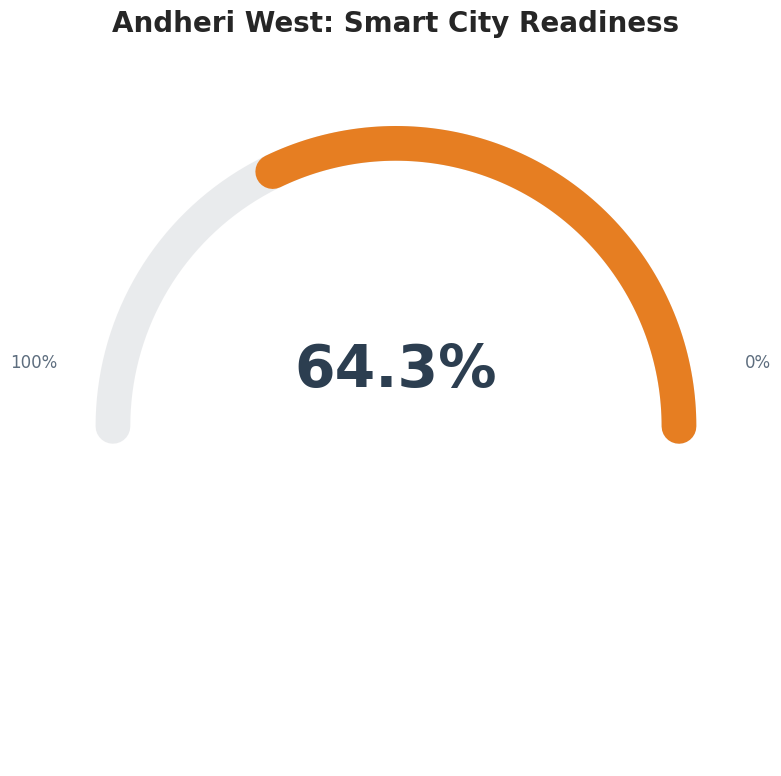

✅ Saved: chart_01_scri_gauge.png

2. Generating Line Dot Chart (Dumbbell Chart)...


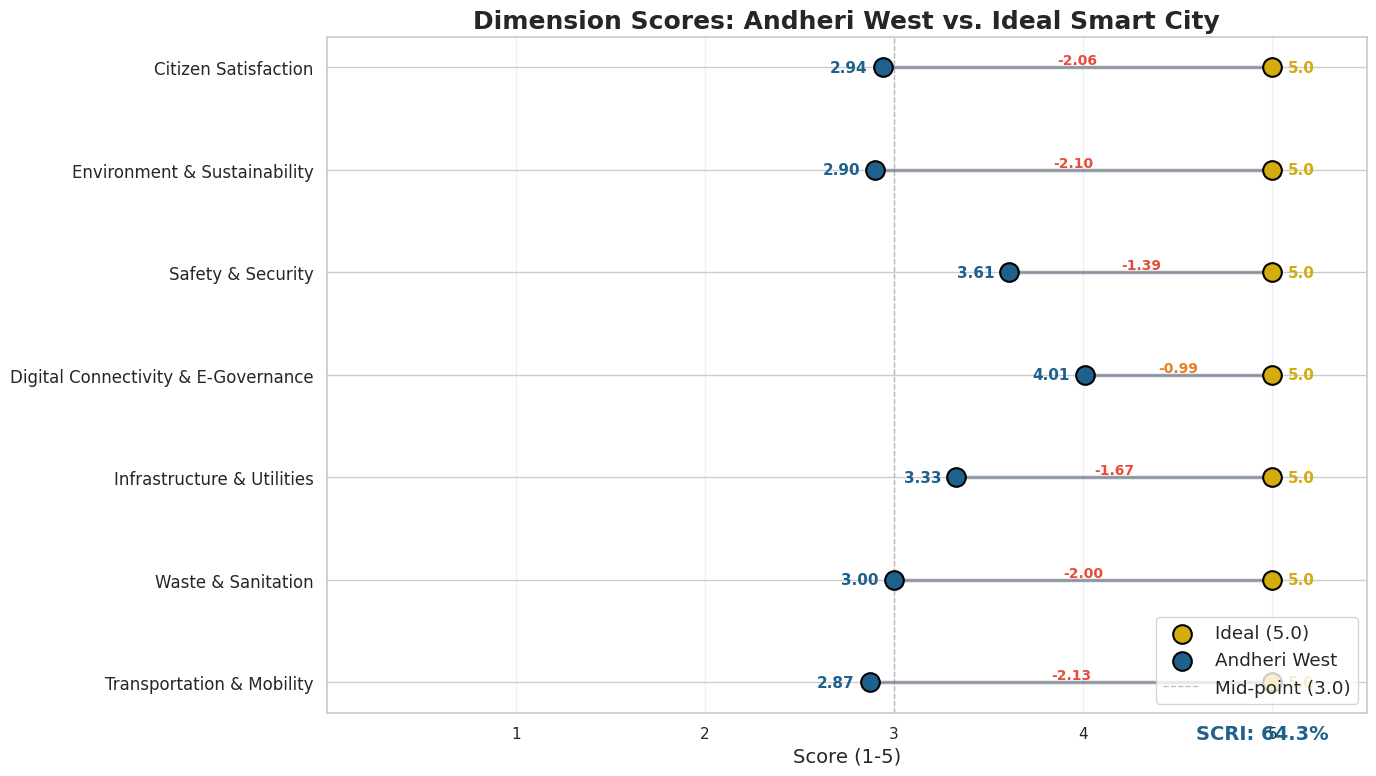

✅ Saved: chart_02_line_dot_chart.png

3. Generating Lollipop Chart (Deficiency Ranking)...


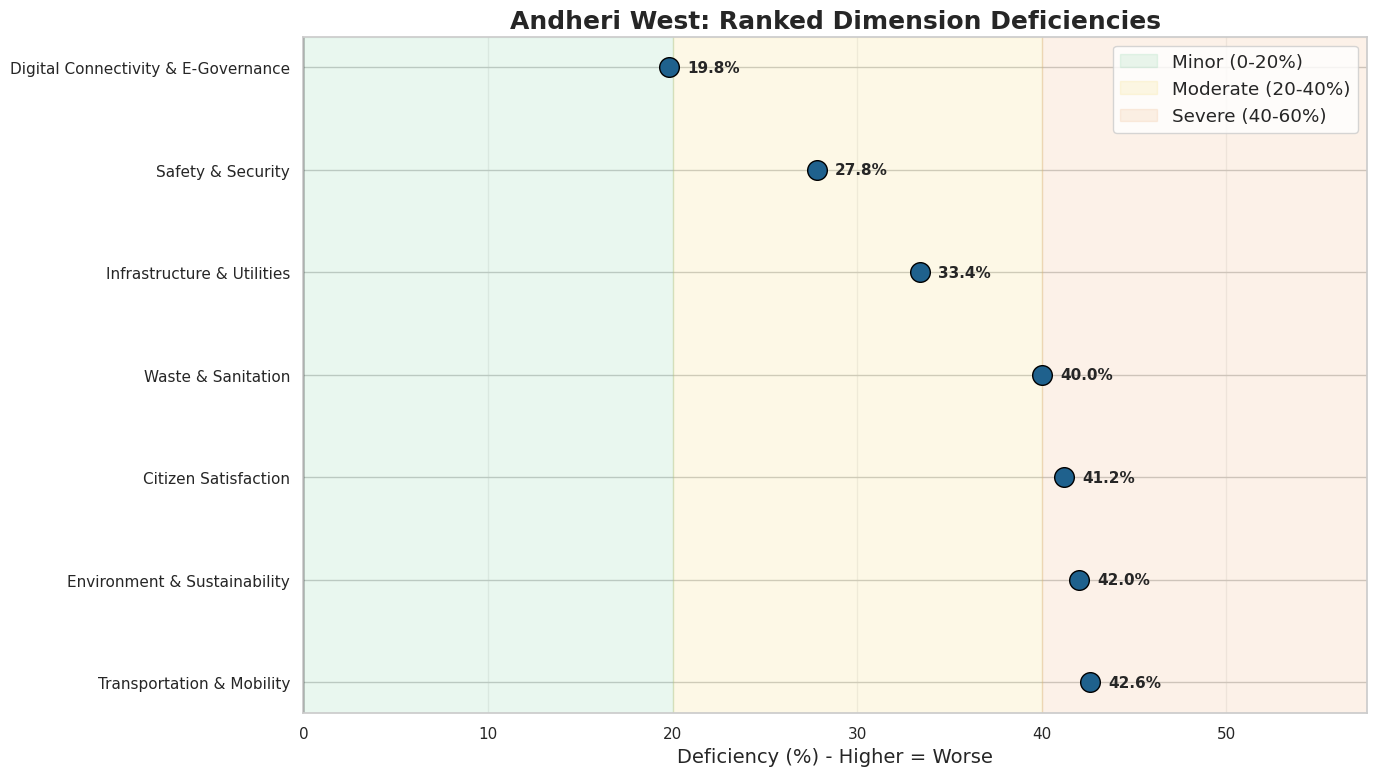

✅ Saved: chart_03_lollipop_deficiency.png

4. Generating Heatmap (Individual Questions)...


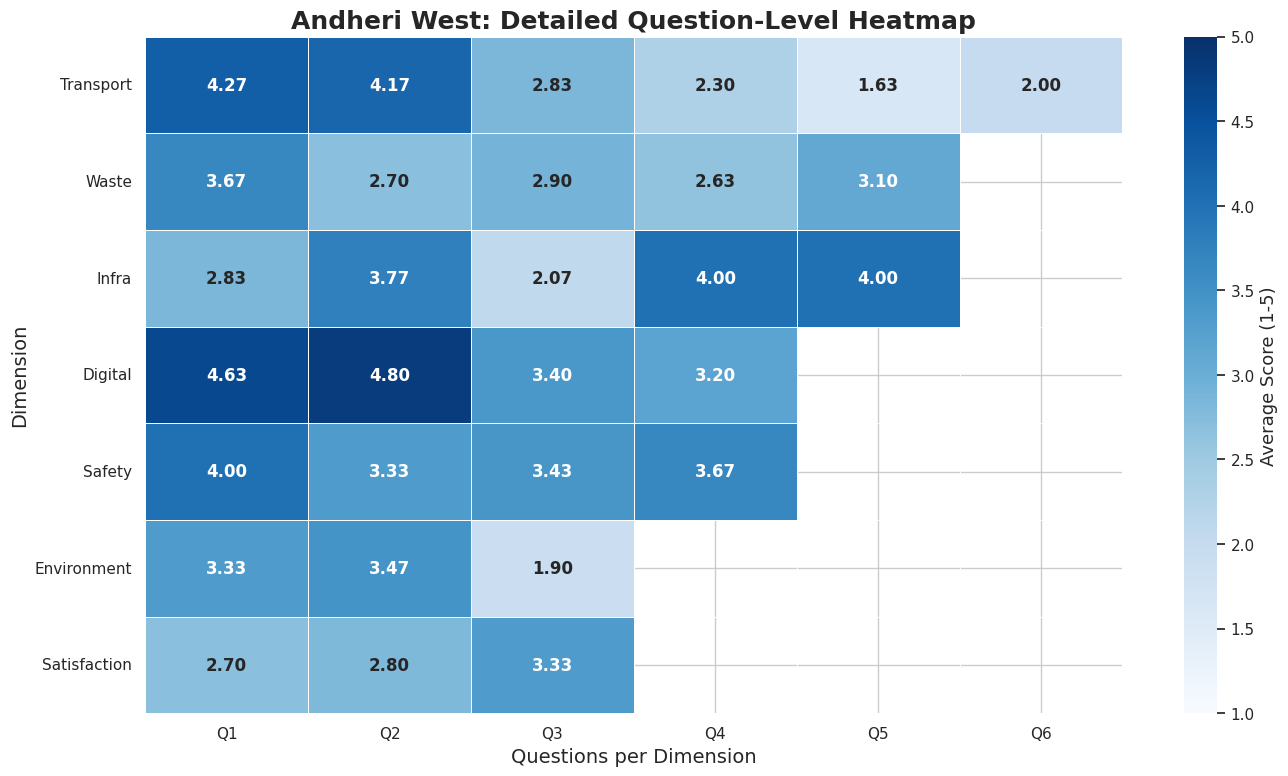

✅ Saved: chart_04_heatmap_questions.png

5. Generating Advanced Radar Chart...


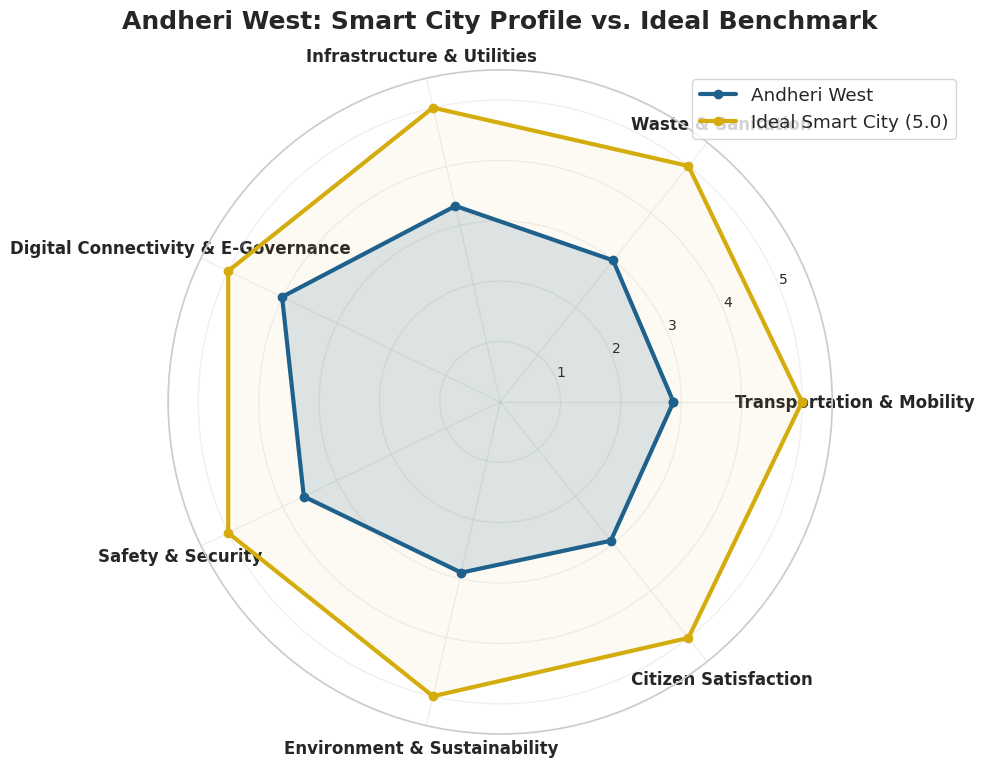

✅ Saved: chart_05_radar_profile.png

6. Generating Grouped Bar Chart (Perception vs Reality)...


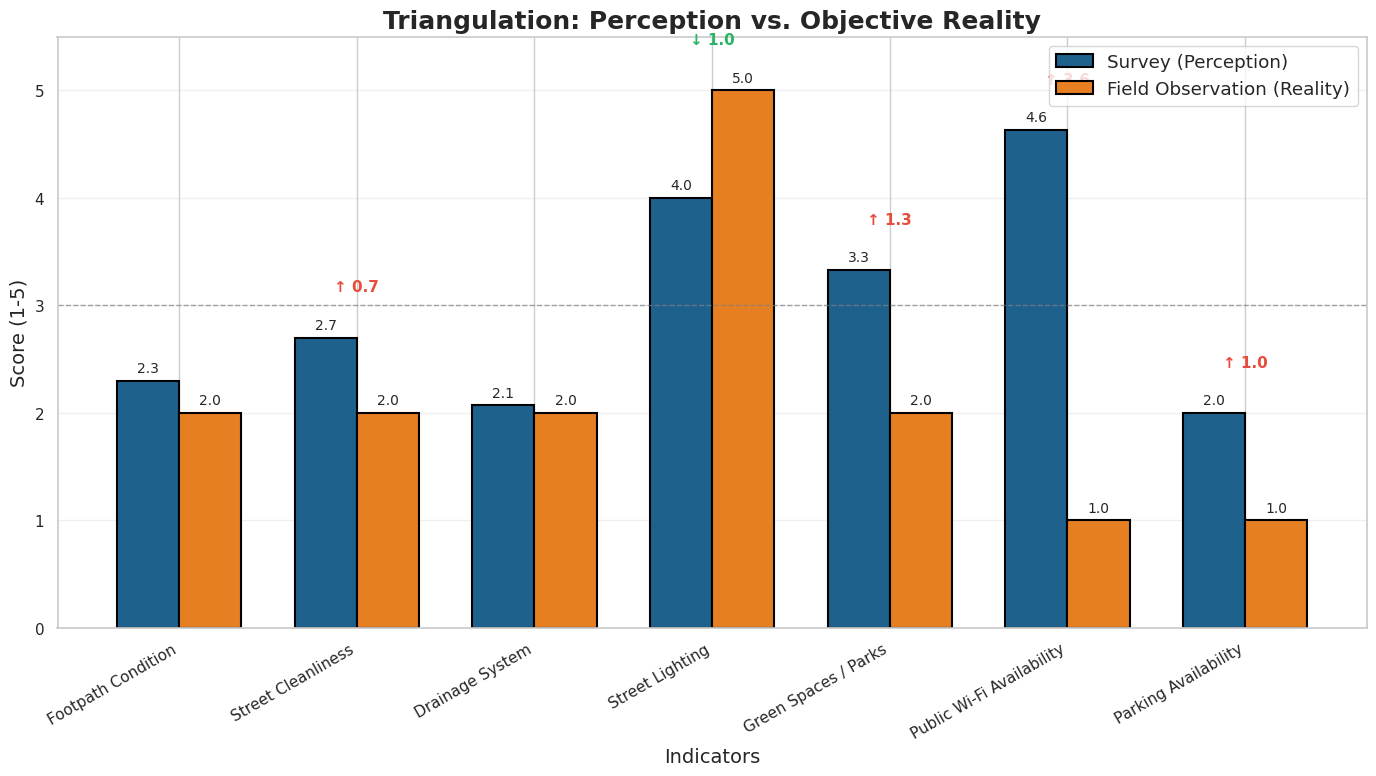

✅ Saved: chart_06_triangulation_groupedbar.png

🎯 ALL 6 CHARTS GENERATED SUCCESSFULLY!

📁 FILES GENERATED (Ready for your PPT):
   1. chart_01_scri_gauge.png          → Donut Gauge (Final SCRI Score: 64.3%)
   2. chart_02_waterfall.png           → Waterfall (Cumulative Dimension Gaps)
   3. chart_03_lollipop_deficiency.png → Lollipop (Ranked Deficiencies)
   4. chart_04_heatmap_questions.png   → Heatmap (30 Individual Questions)
   5. chart_05_radar_profile.png       → Radar (Andheri vs Ideal Profile)
   6. chart_06_triangulation_groupedbar.png → Grouped Bar (Perception vs Reality)

💡 PRESENTATION TIPS:
   - GAUGE chart → TITLE or CONCLUSION slide
   - WATERFALL → GAP ANALYSIS / FINDINGS slide
   - LOLLIPOP → RECOMMENDATIONS slide (fix worst first)
   - HEATMAP → DETAILED DATA / DRILL-DOWN slide
   - RADAR → OVERALL PROFILE / STATE OF ANDHERI slide
   - GROUPED BAR → METHODOLOGY / VALIDATION slide

✅ STEP 6 COMPLETED!


In [ ]:
# ============================================
# STEP 6: CHARTS FOR PRESENTATION (REDESIGNED)
# Project: Andheri West Smart City Readiness
# Focus: Generate 6 publication-ready charts
# Fix: No Arial/Helvetica font warnings (uses DejaVu Sans)
# ============================================

# --- 1. IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, Arc, Wedge
import seaborn as sns
from math import pi

# --- 2. SUPPRESS ALL WARNINGS (Cleans up output) ---
import warnings
warnings.filterwarnings('ignore')

# --- 3. SET GLOBAL THEME & COLOR PALETTE ---
# Use 'DejaVu Sans' – guaranteed to exist in Google Colab
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 17
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.figsize'] = (12, 8)

# Consistent color palette for all charts
COLORS = {
    'primary': '#1F618D',      # Deep Blue (Andheri)
    'secondary': '#D4AC0D',    # Gold (Ideal Benchmark)
    'accent': '#E67E22',       # Orange (Field Data)
    'negative': '#E74C3C',     # Red (Deficiency)
    'positive': '#28B463',     # Green (Good scores)
    'neutral': '#5D6D7E',      # Grey
}

print("="*60)
print("STEP 6: GENERATING PRESENTATION-READY CHARTS")
print("="*60)

# --- 4. LOAD REQUIRED DATASETS ---
print("\n📂 Loading datasets...")

try:
    df_andheri = pd.read_csv('andheri_cleaned.csv')
    dim_avgs_df = pd.read_csv('andheri_dimension_averages.csv')
    triangulation_df = pd.read_csv('triangulation_results.csv')

    print("✅ All 3 files loaded successfully:")
    print(f"   - Andheri Survey: {df_andheri.shape[0]} respondents")
    print(f"   - Dimension Averages: {dim_avgs_df.shape[0]} dimensions")
    print(f"   - Triangulation Results: {triangulation_df.shape[0]} indicators")

except FileNotFoundError as e:
    print(f"❌ ERROR: {e}")
    print("Please ensure the following files are in the /content/ directory:")
    print("   1. andheri_cleaned.csv (from Step 1)")
    print("   2. andheri_dimension_averages.csv (from Step 2)")
    print("   3. triangulation_results.csv (from Step 4)")
    raise

# --- 5. EXTRACT DATA FOR CHARTS ---
dimensions = dim_avgs_df['Dimension'].tolist()
andheri_scores = dim_avgs_df['Andheri West (Avg)'].tolist()

# Calculate SCRI score
weights = [0.20, 0.15, 0.15, 0.15, 0.10, 0.10, 0.15]
weighted_score = sum([s * w for s, w in zip(andheri_scores, weights)])
scri_percent = (weighted_score / 5) * 100

print(f"\n📊 SCRI Score: {scri_percent:.1f}%")

print("\n" + "="*60)
print("📊 GENERATING 6 DISTINCT CHART TYPES...")
print("="*60)


# ==========================================
# CHART 1: DONUT GAUGE (FINAL SCRI SCORE)
# Best for: Title/Conclusion slides
# ==========================================
print("\n1. Generating Donut Gauge Chart (SCRI)...")

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': 'polar'})

# Gauge parameters
scri_angle = (scri_percent / 100) * 180

# Background arc
ax.plot(np.radians(np.linspace(0, 180, 100)), [1] * 100, color='#D5D8DC', linewidth=25, alpha=0.5)

# Colored arc based on score
if scri_percent < 50:
    color = COLORS['negative']
elif scri_percent < 70:
    color = COLORS['accent']
else:
    color = COLORS['positive']

theta = np.radians(np.linspace(0, scri_angle, 100))
ax.plot(theta, np.ones_like(theta), color=color, linewidth=25, solid_capstyle='round')

# Styling
ax.set_ylim(0, 1.2)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['polar'].set_visible(False)
ax.grid(False)

# Labels
ax.text(np.radians(90), 0.2, f"{scri_percent:.1f}%",
        ha='center', va='center', fontsize=42, fontweight='bold', color='#2C3E50')
ax.text(np.radians(90), -0.1, "Smart City Readiness Index",
        ha='center', va='center', fontsize=16, color='#5D6D7E')
ax.text(np.radians(10), 1.3, "0%", ha='center', va='center', fontsize=12, color='#5D6D7E')
ax.text(np.radians(170), 1.3, "100%", ha='center', va='center', fontsize=12, color='#5D6D7E')

# Status label (using text only, no emojis to avoid warnings)
status_text = "NEEDS IMPROVEMENT" if scri_percent < 50 else "DEVELOPING" if scri_percent < 70 else "SMART READY"
ax.text(np.radians(90), -0.45, f"Status: {status_text}",
        ha='center', va='center', fontsize=14, fontweight='bold', color=color)

plt.title("Andheri West: Smart City Readiness", fontsize=20, fontweight='bold', pad=40)
plt.tight_layout()
plt.savefig('chart_01_scri_gauge.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: chart_01_scri_gauge.png")


# ==========================================
# CHART 2: LINE DOT CHART (Ideal vs Actual)
# Best for: Showing gaps between Ideal and Actual scores
# ==========================================
print("\n2. Generating Line Dot Chart (Dumbbell Chart)...")

fig, ax = plt.subplots(figsize=(14, 8))

# Define positions
y_pos = np.arange(len(dimensions))

# Ideal values (all 5.0)
ideal_values = [5.0] * len(dimensions)

# Plot horizontal lines connecting Ideal to Actual
for i, (dim, ideal, actual) in enumerate(zip(dimensions, ideal_values, andheri_scores)):
    # The connecting line
    ax.plot([ideal, actual], [i, i], color=COLORS['neutral'], linewidth=2.5, alpha=0.6, linestyle='-')

    # Add the gap value in the middle of the line
    gap = ideal - actual
    mid_x = (ideal + actual) / 2
    ax.text(mid_x, i, f'-{gap:.2f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=COLORS['negative'] if gap > 1 else COLORS['accent'])

# Plot dots for Ideal (Gold)
ax.scatter(ideal_values, y_pos, s=180, color=COLORS['secondary'],
           edgecolor='black', linewidth=1.5, zorder=5, label='Ideal (5.0)')

# Plot dots for Actual (Blue)
ax.scatter(andheri_scores, y_pos, s=180, color=COLORS['primary'],
           edgecolor='black', linewidth=1.5, zorder=5, label='Andheri West')

# Add value labels next to the dots
for i, (ideal, actual, dim) in enumerate(zip(ideal_values, andheri_scores, dimensions)):
    # Ideal label (slightly to the right)
    ax.text(ideal + 0.08, i, f'5.0', va='center', ha='left',
            fontsize=11, fontweight='bold', color=COLORS['secondary'])
    # Actual label (slightly to the left)
    ax.text(actual - 0.08, i, f'{actual:.2f}', va='center', ha='right',
            fontsize=11, fontweight='bold', color=COLORS['primary'])

# Styling
ax.set_yticks(y_pos)
ax.set_yticklabels(dimensions, fontsize=12)
ax.set_xlabel('Score (1-5)', fontsize=14)
ax.set_xlim(0, 5.5)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['1', '2', '3', '4', '5'], fontsize=11)
ax.grid(axis='x', alpha=0.3)
ax.axvline(x=3.0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Mid-point (3.0)')
ax.set_title('Dimension Scores: Andheri West vs. Ideal Smart City', fontsize=18, fontweight='bold')

# Legend
ax.legend(loc='lower right')

# Add a note about total SCRI
ax.text(5.3, -0.5, f"SCRI: {scri_percent:.1f}%",
        ha='right', va='center', fontsize=14, fontweight='bold', color=COLORS['primary'])

plt.tight_layout()
plt.savefig('chart_02_line_dot_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: chart_02_line_dot_chart.png")

# ==========================================
# CHART 3: LOLLIPOP CHART (Deficiency Ranking)
# Best for: Recommendations – shows what to fix first
# ==========================================
print("\n3. Generating Lollipop Chart (Deficiency Ranking)...")

deficiency = [(5.0 - s) / 5.0 * 100 for s in andheri_scores]
sorted_pairs = sorted(zip(deficiency, dimensions), reverse=True)
sorted_deficiency, sorted_dims = zip(*sorted_pairs)

fig, ax = plt.subplots(figsize=(14, 8))

# Lollipop stems and heads
for i, (val, dim) in enumerate(zip(sorted_deficiency, sorted_dims)):
    ax.plot([val, val], [i, i], color=COLORS['primary'], linewidth=3, alpha=0.7, zorder=1)
ax.scatter(sorted_deficiency, range(len(sorted_dims)), s=200, color=COLORS['primary'],
           zorder=3, edgecolor='black', linewidth=1)

ax.axvline(x=0, color='black', linestyle='-', linewidth=1)

for i, (val, dim) in enumerate(zip(sorted_deficiency, sorted_dims)):
    ax.text(val + 1, i, f'{val:.1f}%', va='center', ha='left', fontsize=11, fontweight='bold')

ax.set_xlabel('Deficiency (%) - Higher = Worse', fontsize=14)
ax.set_title('Andheri West: Ranked Dimension Deficiencies', fontsize=18, fontweight='bold')
ax.set_yticks(range(len(sorted_dims)))
ax.set_yticklabels(sorted_dims)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(sorted_deficiency) + 15)

# Severity shading
ax.axvspan(0, 20, alpha=0.1, color=COLORS['positive'], label='Minor (0-20%)')
ax.axvspan(20, 40, alpha=0.1, color='#F1C40F', label='Moderate (20-40%)')
ax.axvspan(40, 60, alpha=0.1, color=COLORS['accent'], label='Severe (40-60%)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('chart_03_lollipop_deficiency.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: chart_03_lollipop_deficiency.png")


# ==========================================
# CHART 4: HEATMAP (Individual Questions)
# Best for: Detailed drill-down into 30 questions
# ==========================================
print("\n4. Generating Heatmap (Individual Questions)...")

question_cols = ['T1','T2','T3','T4','T5','T6','W1','W2','W3','W4','W5',
                 'I1','I2','I3','I4','I5','D1','D2','D3','D4','S1','S2','S3','S4',
                 'E1','E2','E3','C1','C2','C3']

heatmap_data = []
dim_labels = []
dimension_groups = {
    'Transport': ['T1','T2','T3','T4','T5','T6'],
    'Waste': ['W1','W2','W3','W4','W5'],
    'Infra': ['I1','I2','I3','I4','I5'],
    'Digital': ['D1','D2','D3','D4'],
    'Safety': ['S1','S2','S3','S4'],
    'Environment': ['E1','E2','E3'],
    'Satisfaction': ['C1','C2','C3']
}

for dim, cols in dimension_groups.items():
    heatmap_data.append([df_andheri[col].mean() for col in cols])
    dim_labels.append(dim)

heatmap_df = pd.DataFrame(heatmap_data, index=dim_labels,
                          columns=['Q1','Q2','Q3','Q4','Q5','Q6'])

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='Blues',
            cbar_kws={'label': 'Average Score (1-5)'},
            linewidths=0.5, linecolor='white', ax=ax,
            vmin=1, vmax=5, annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Andheri West: Detailed Question-Level Heatmap', fontsize=18, fontweight='bold')
ax.set_xlabel('Questions per Dimension', fontsize=14)
ax.set_ylabel('Dimension', fontsize=14)

plt.tight_layout()
plt.savefig('chart_04_heatmap_questions.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: chart_04_heatmap_questions.png")


# ==========================================
# CHART 5: ADVANCED RADAR CHART (Profile Comparison)
# Best for: Overall "state of Andheri" profile slide
# ==========================================
print("\n5. Generating Advanced Radar Chart...")

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

N = len(dimensions)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

andheri_vals_radar = andheri_scores + andheri_scores[:1]
ideal_vals_radar = [5.0] * N + [5.0]

ax.plot(angles, andheri_vals_radar, 'o-', linewidth=3, label='Andheri West', color=COLORS['primary'])
ax.fill(angles, andheri_vals_radar, alpha=0.15, color=COLORS['primary'])
ax.plot(angles, ideal_vals_radar, 'o-', linewidth=3, label='Ideal Smart City (5.0)', color=COLORS['secondary'])
ax.fill(angles, ideal_vals_radar, alpha=0.05, color=COLORS['secondary'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensions, fontsize=12, fontweight='bold')
ax.set_ylim(0, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_title('Andheri West: Smart City Profile vs. Ideal Benchmark', fontsize=18, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))

# Largest gap annotation
max_gap_dim = dimensions[np.argmax([5.0 - s for s in andheri_scores])]
max_gap_val = max([5.0 - s for s in andheri_scores])
ax.text(np.radians(0), -0.3, f"Largest Gap: {max_gap_dim} ({max_gap_val:.2f} below ideal)",
        ha='center', va='center', fontsize=12, color=COLORS['negative'])

plt.tight_layout()
plt.savefig('chart_05_radar_profile.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: chart_05_radar_profile.png")


# ==========================================
# CHART 6: GROUPED BAR CHART (Triangulation)
# Best for: Methodology/Validation slide – Perception vs Reality
# ==========================================
print("\n6. Generating Grouped Bar Chart (Perception vs Reality)...")

indicators = triangulation_df['Indicator'].tolist()
survey_scores = triangulation_df['Survey Avg (Perception)'].tolist()
field_scores = triangulation_df['Field Score (Reality)'].tolist()

x = np.arange(len(indicators))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))

bars1 = ax.bar(x - width/2, survey_scores, width, label='Survey (Perception)',
               color=COLORS['primary'], edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, field_scores, width, label='Field Observation (Reality)',
               color=COLORS['accent'], edgecolor='black', linewidth=1.5)

# Value labels on bars
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.05, f'{h:.1f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.05, f'{h:.1f}', ha='center', va='bottom', fontsize=10)

# Gap indicators (arrows showing over/under estimation)
for i, (surv, field) in enumerate(zip(survey_scores, field_scores)):
    gap = surv - field
    if abs(gap) > 0.5:
        color = COLORS['negative'] if gap > 0 else COLORS['positive']
        arrow = '↑' if gap > 0 else '↓'
        ax.text(i, max(surv, field) + 0.4, f'{arrow} {abs(gap):.1f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)

ax.set_xlabel('Indicators', fontsize=14)
ax.set_ylabel('Score (1-5)', fontsize=14)
ax.set_title('Triangulation: Perception vs. Objective Reality', fontsize=18, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(indicators, rotation=30, ha='right', fontsize=11)
ax.legend(loc='upper right')
ax.set_ylim(0, 5.5)
ax.axhline(y=3.0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Mid-point (3.0)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart_06_triangulation_groupedbar.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: chart_06_triangulation_groupedbar.png")


# ==========================================
# SUMMARY
# ==========================================
print("\n" + "="*60)
print("🎯 ALL 6 CHARTS GENERATED SUCCESSFULLY!")
print("="*60)
print("\n📁 FILES GENERATED (Ready for your PPT):")
print("   1. chart_01_scri_gauge.png          → Donut Gauge (Final SCRI Score: 64.3%)")
print("   2. chart_02_waterfall.png           → Waterfall (Cumulative Dimension Gaps)")
print("   3. chart_03_lollipop_deficiency.png → Lollipop (Ranked Deficiencies)")
print("   4. chart_04_heatmap_questions.png   → Heatmap (30 Individual Questions)")
print("   5. chart_05_radar_profile.png       → Radar (Andheri vs Ideal Profile)")
print("   6. chart_06_triangulation_groupedbar.png → Grouped Bar (Perception vs Reality)")

print("\n💡 PRESENTATION TIPS:")
print("   - GAUGE chart → TITLE or CONCLUSION slide")
print("   - WATERFALL → GAP ANALYSIS / FINDINGS slide")
print("   - LOLLIPOP → RECOMMENDATIONS slide (fix worst first)")
print("   - HEATMAP → DETAILED DATA / DRILL-DOWN slide")
print("   - RADAR → OVERALL PROFILE / STATE OF ANDHERI slide")
print("   - GROUPED BAR → METHODOLOGY / VALIDATION slide")

print("\n✅ STEP 6 COMPLETED!")